## **1. EDA**


In [60]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [61]:
df = pd.read_csv('Global_Pollution_Analysis.csv')

In [62]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [63]:
df.shape

(200, 13)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

NO - NULL 

In [65]:
(df == "").sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df_new = df.copy()

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(df_new[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])

     

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new['Country'] = le.fit_transform(df['Country'])
df_new['Year'] = le.fit_transform(df['Year'])
     

In [70]:
df_new.tail()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
195,92,4,-0.968336,-0.765207,-0.862482,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,13,2,-0.878956,0.124351,-0.316683,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,88,11,-0.461800,0.671106,-0.996342,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,170,2,0.845568,-0.030300,0.643326,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01
199,41,10,-0.674489,0.913617,0.336204,36182.44,172.24,5.55,45.96,45405.35,11.72,166.62,30304.59


In [71]:
df.sort_values(by='Year')['Year']

14     2000
10     2000
25     2000
39     2000
42     2000
       ... 
62     2019
169    2019
132    2019
131    2019
157    2019
Name: Year, Length: 200, dtype: int64

So data is from year 2000 to 2019 

Step 2 - Exploratory Data Analysis (EDA)


In [72]:
df_new.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,9.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,0.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,4.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,10.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,14.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,19.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [73]:
# df.describe().corr()

In [74]:
correlation = df_new.corr(numeric_only=True)["Energy_Recovered (in GWh)"]
correlation

Country                                  -0.044316
Year                                      0.088332
Air_Pollution_Index                       0.002997
Water_Pollution_Index                    -0.041828
Soil_Pollution_Index                      0.064076
Industrial_Waste (in tons)               -0.161309
Energy_Recovered (in GWh)                 1.000000
CO2_Emissions (in MT)                     0.024758
Renewable_Energy (%)                      0.043533
Plastic_Waste_Produced (in tons)         -0.072946
Energy_Consumption_Per_Capita (in MWh)   -0.030284
Population (in millions)                 -0.075100
GDP_Per_Capita (in USD)                   0.004535
Name: Energy_Recovered (in GWh), dtype: float64

<Axes: >

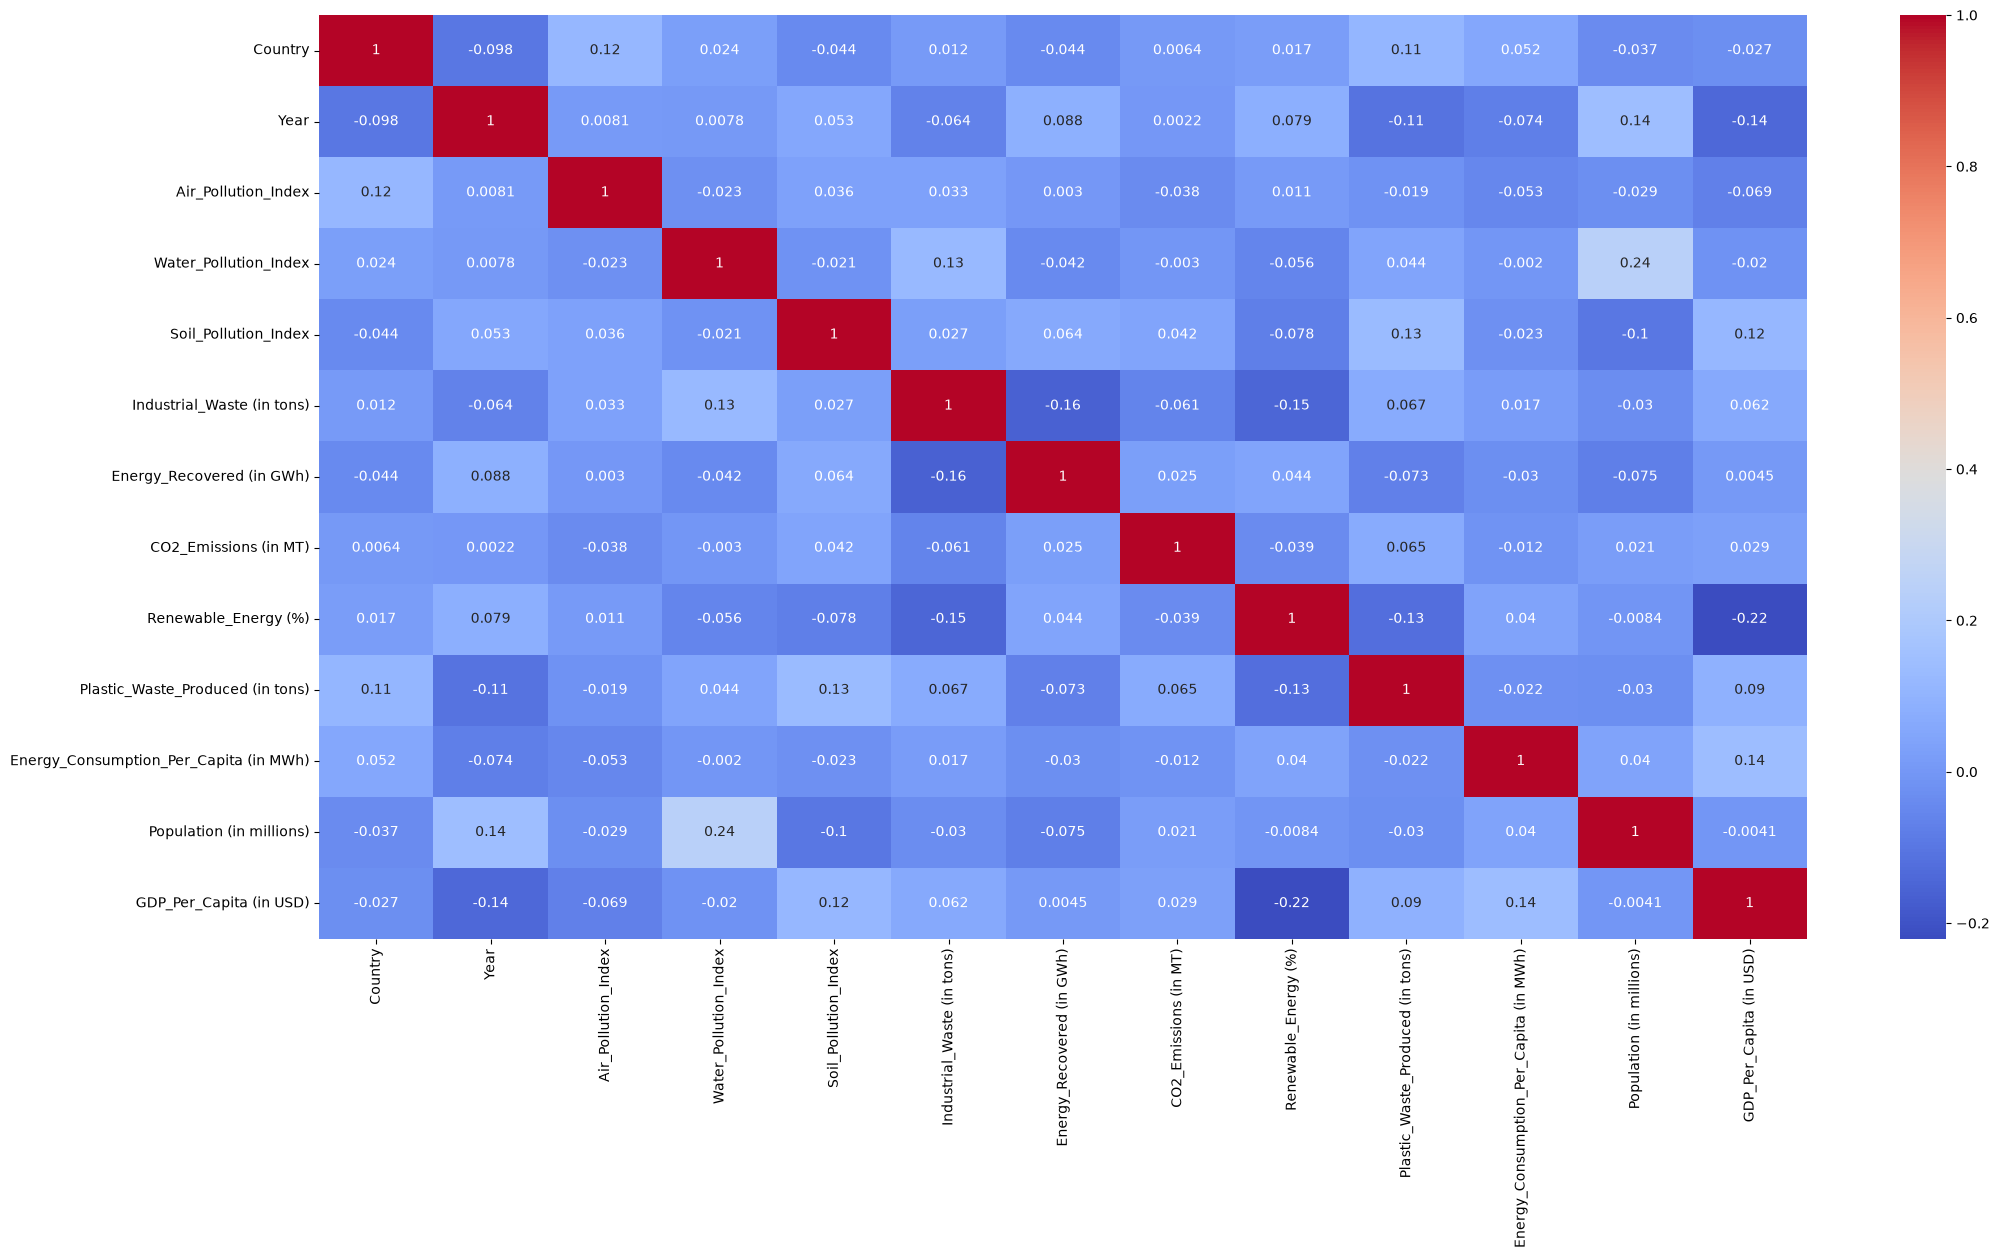

In [75]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True ,cmap = "coolwarm")

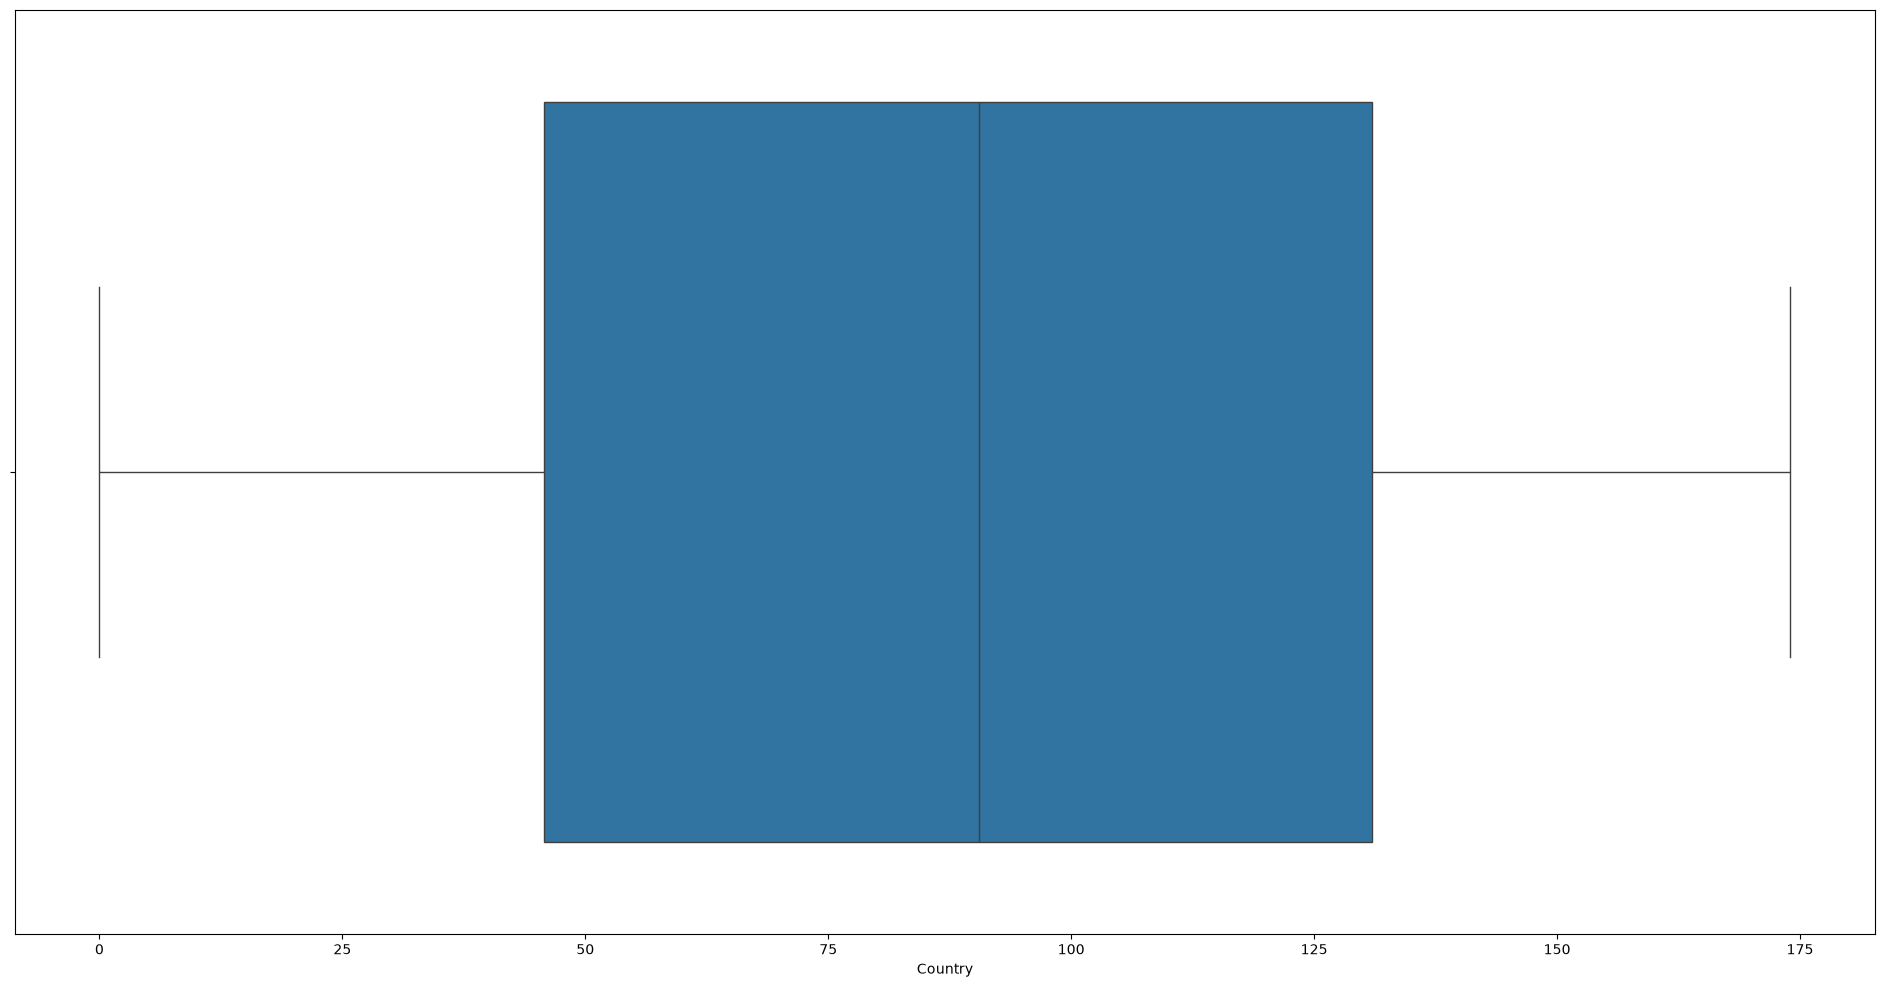

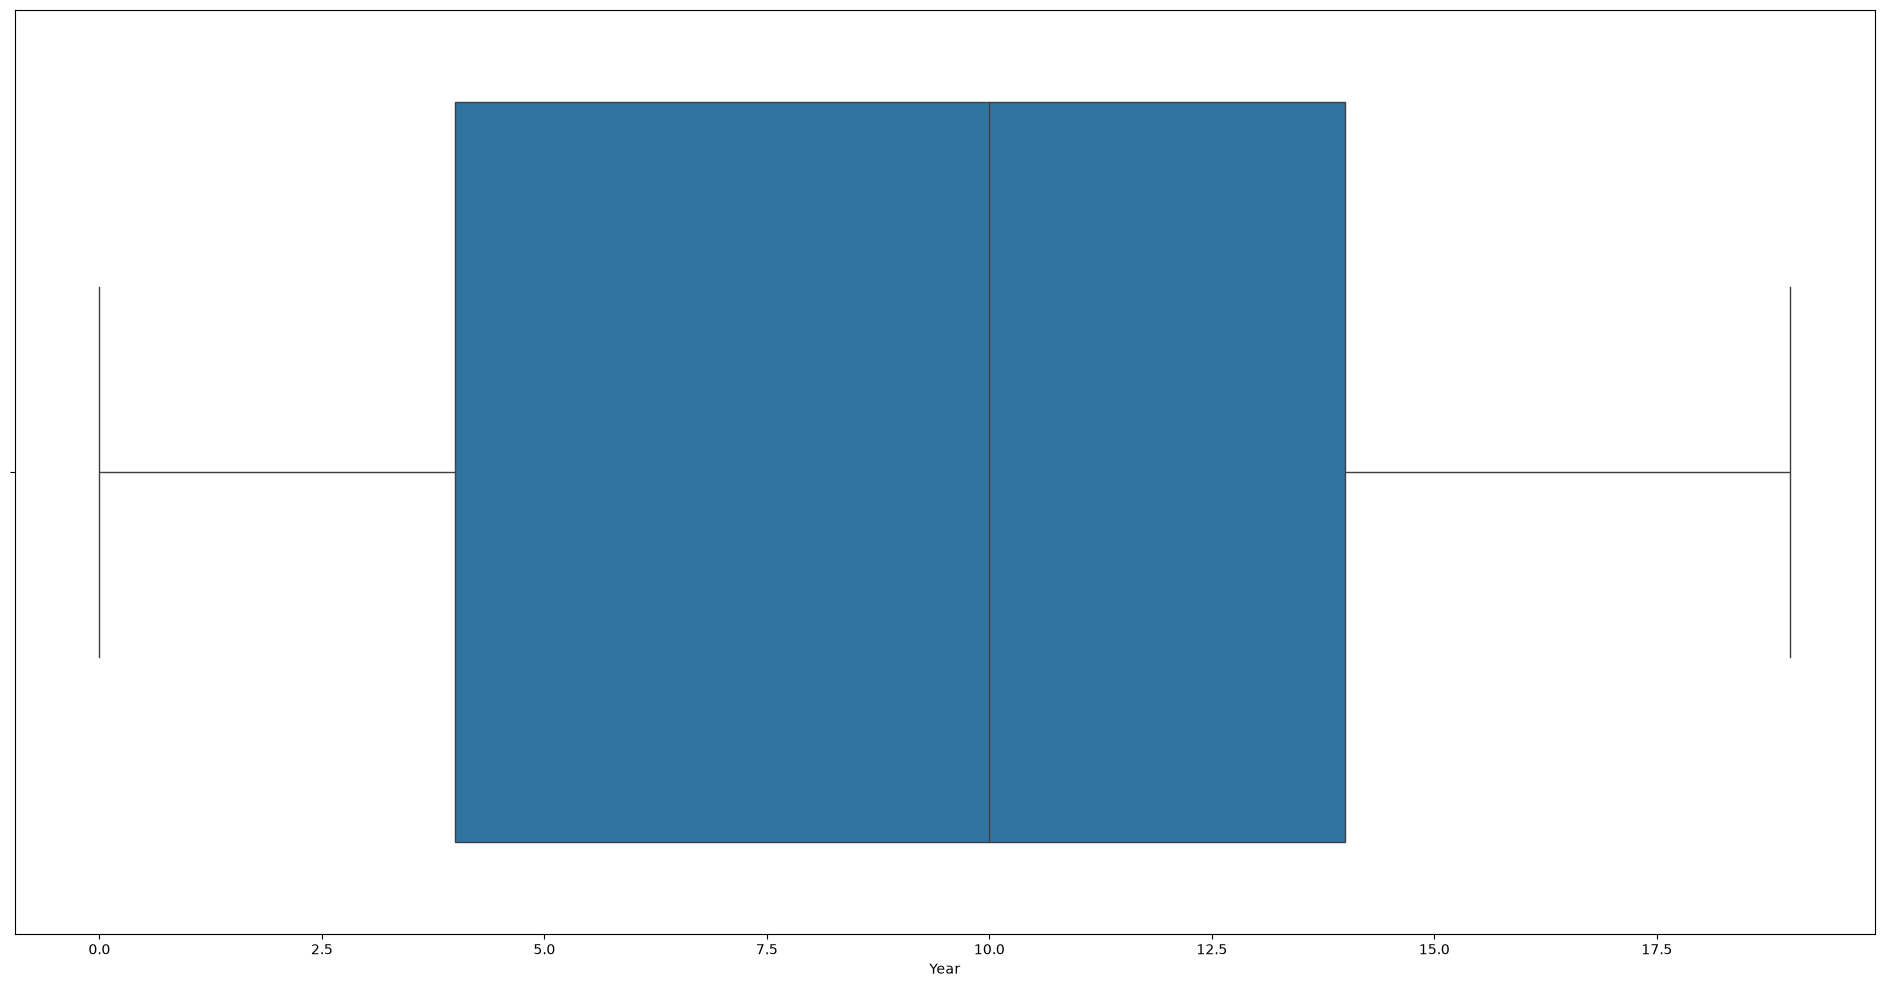

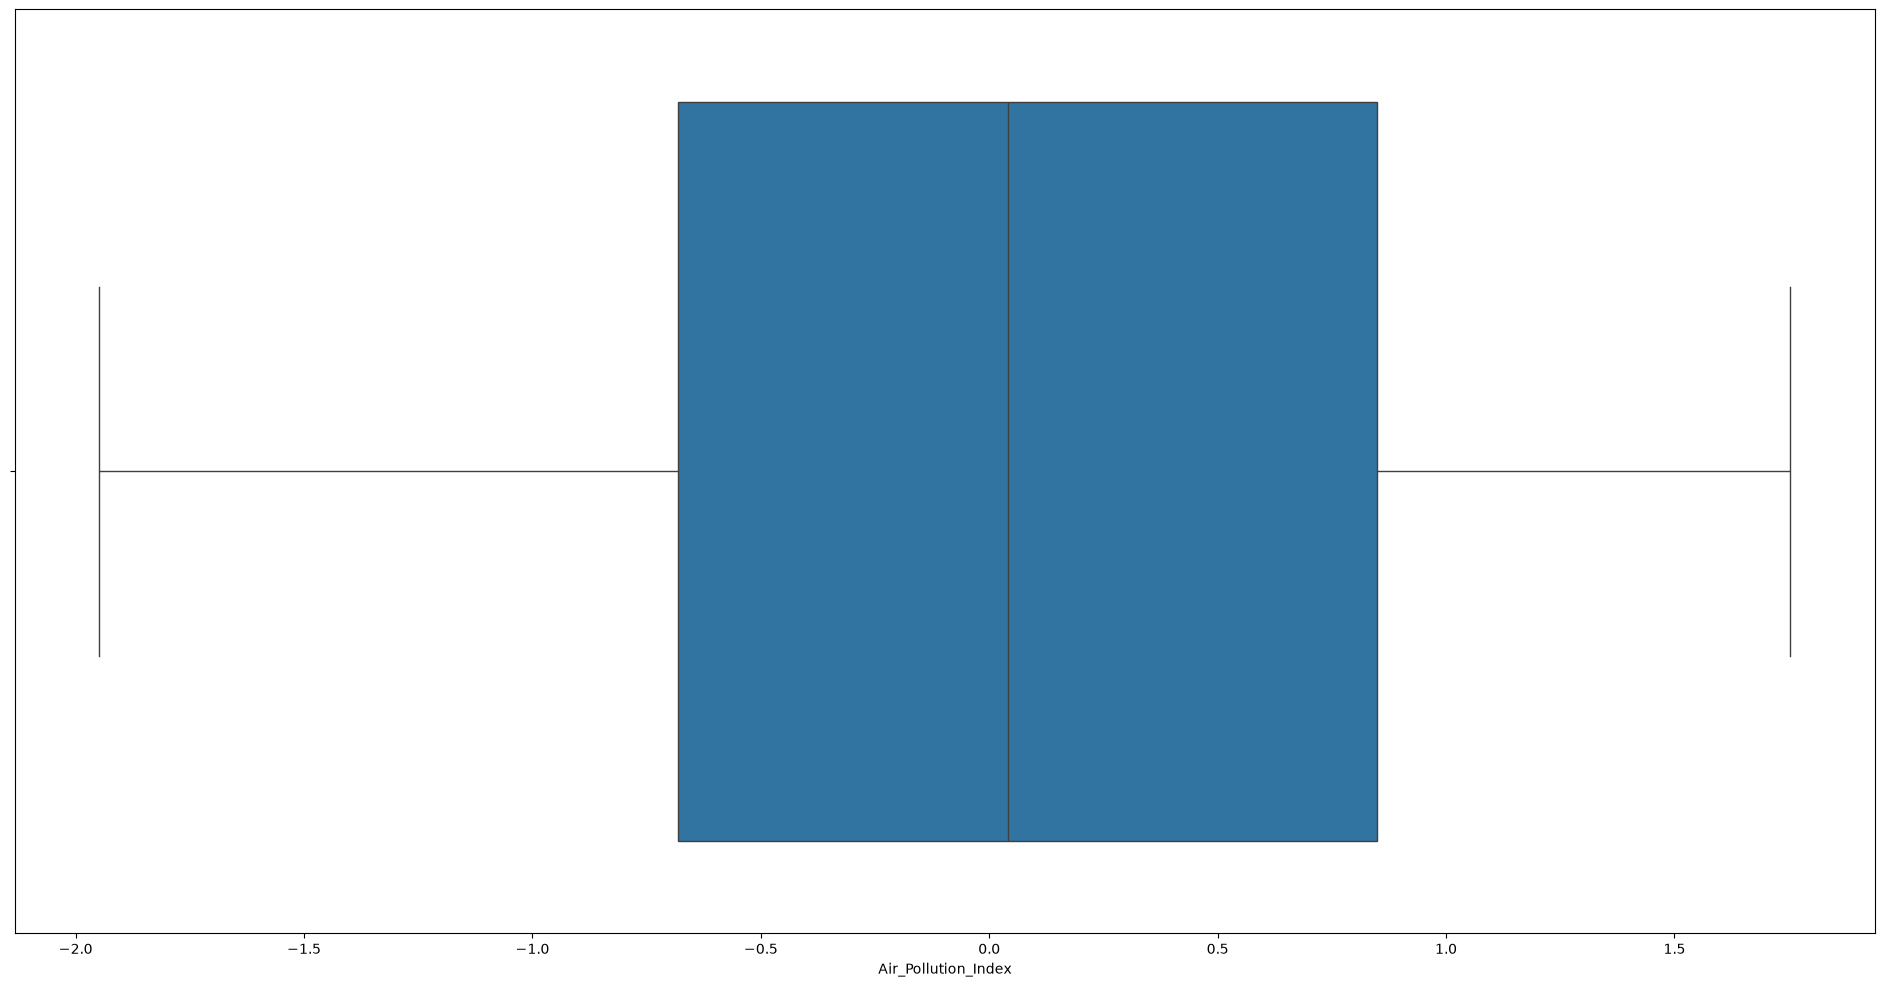

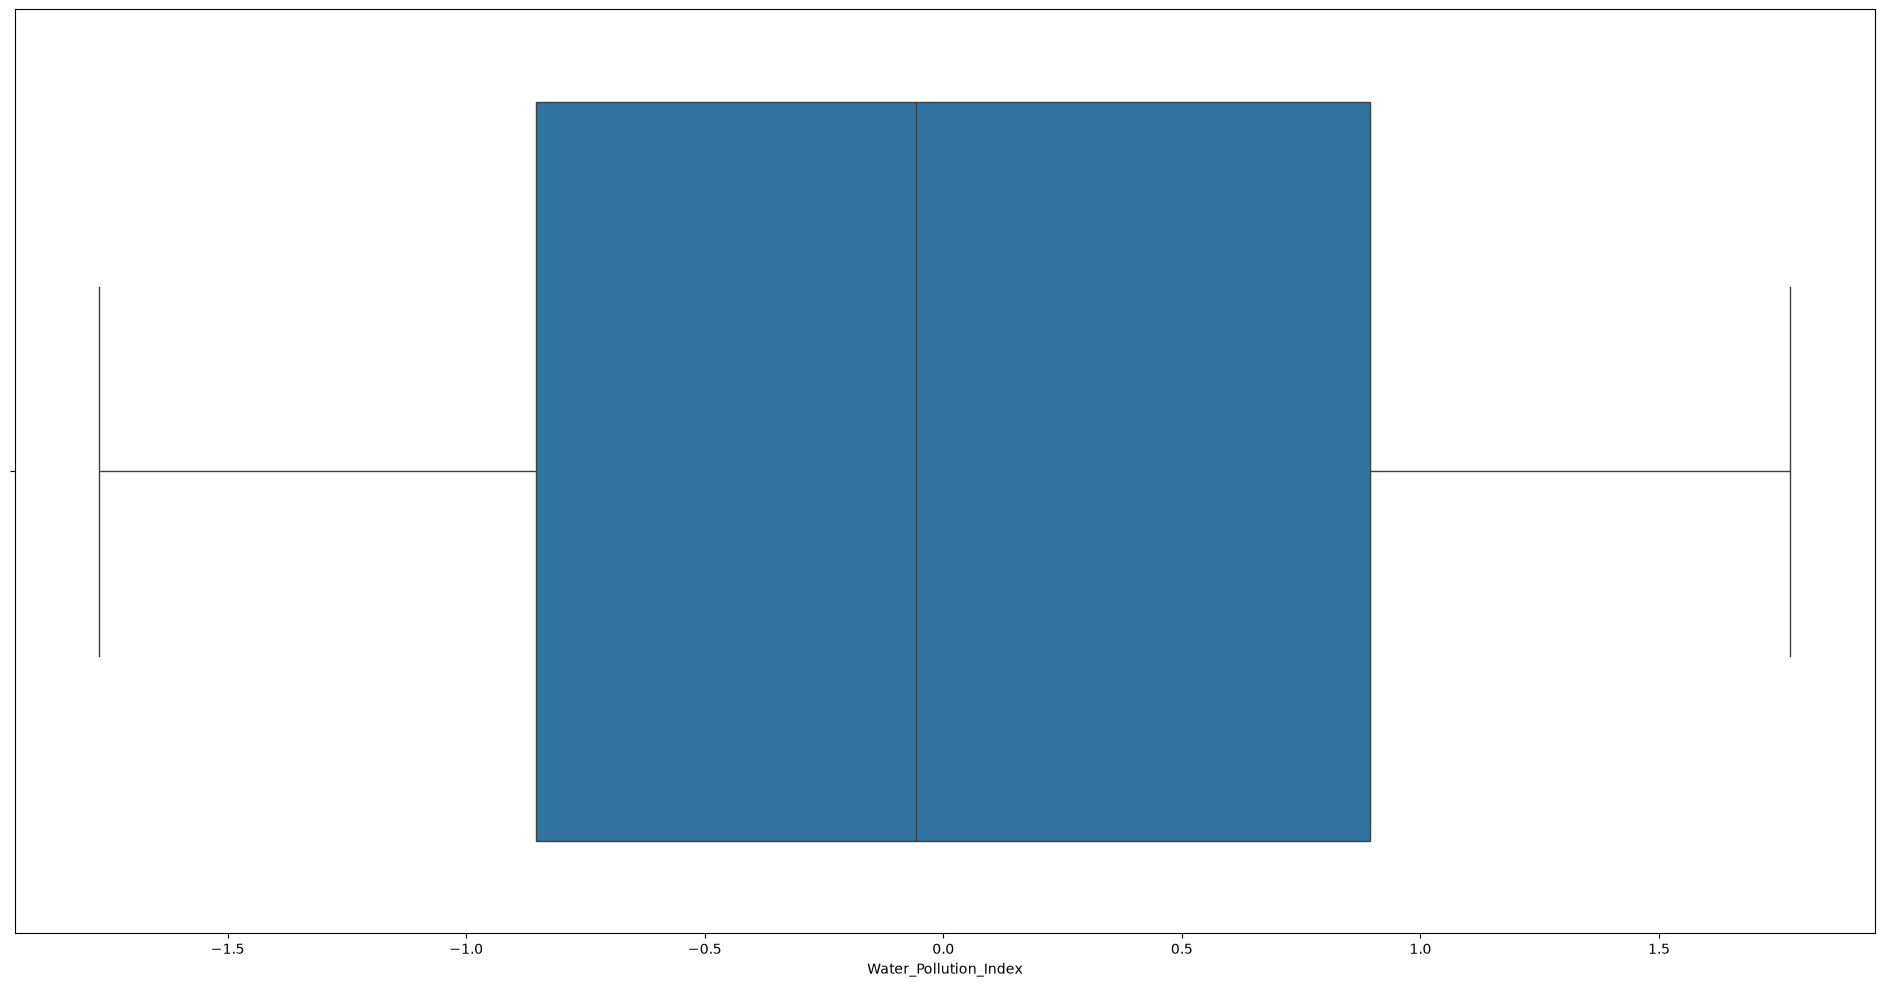

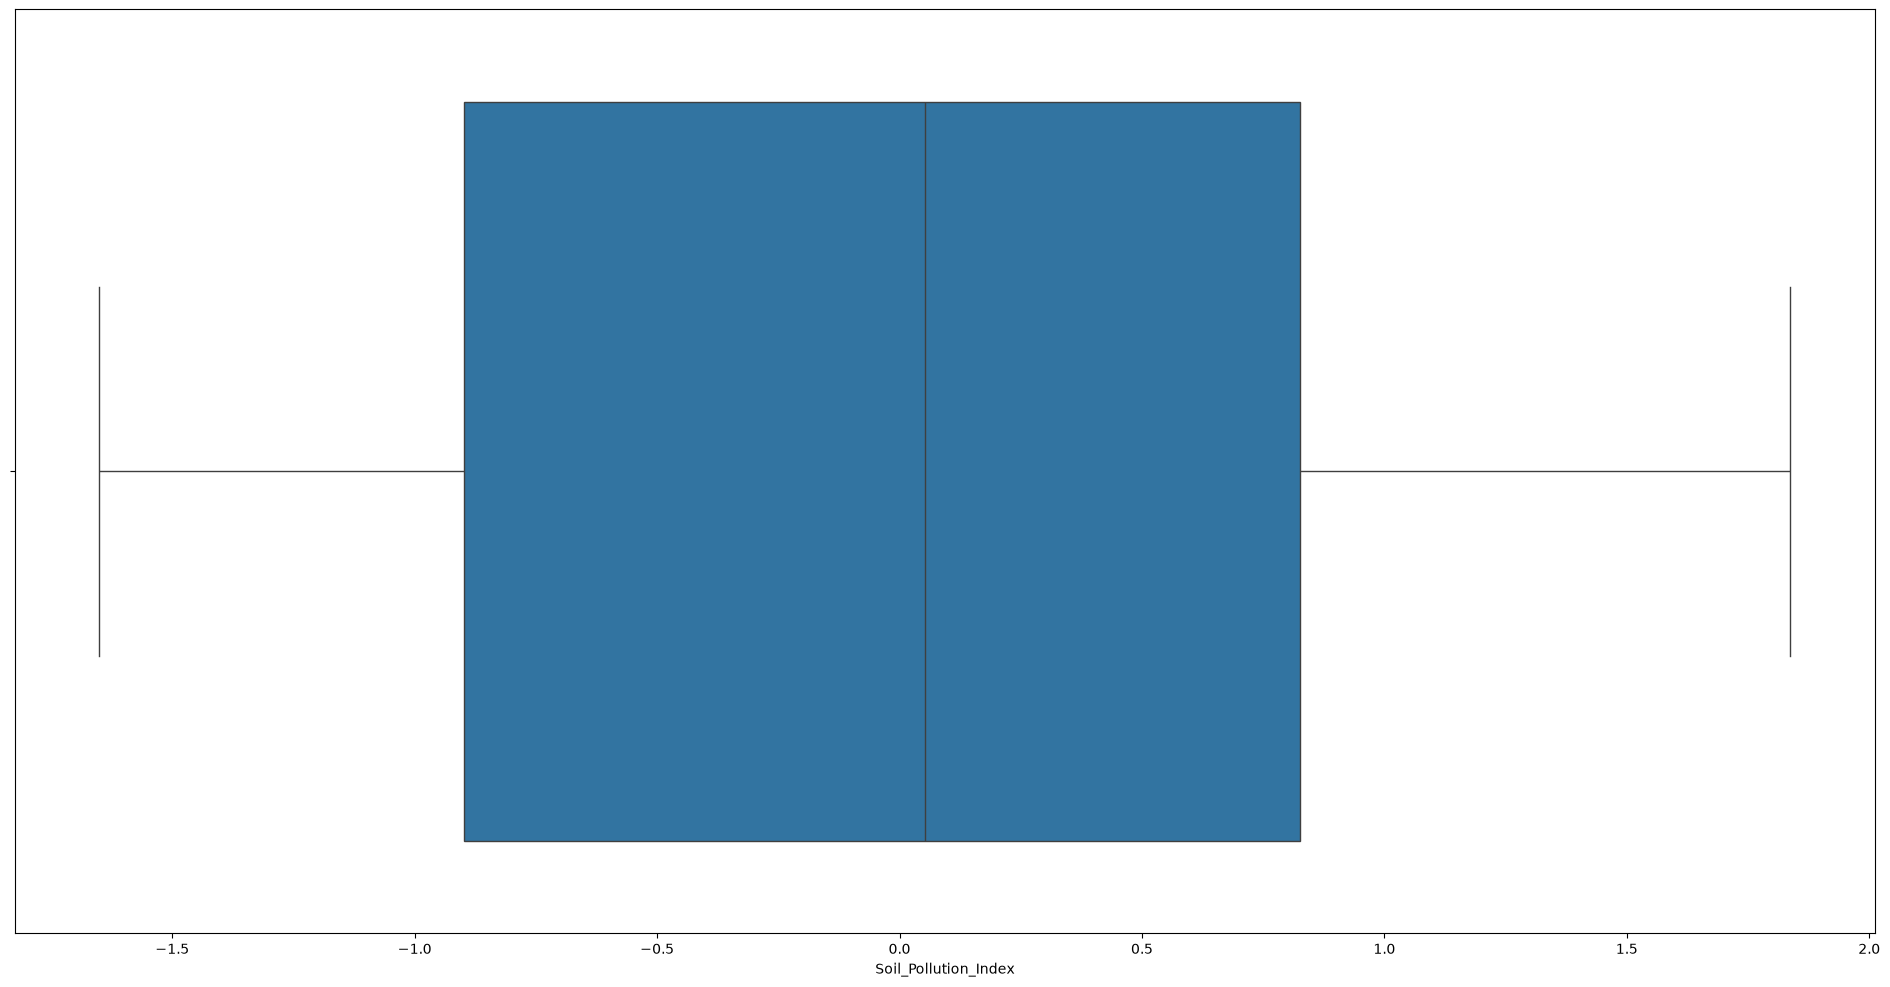

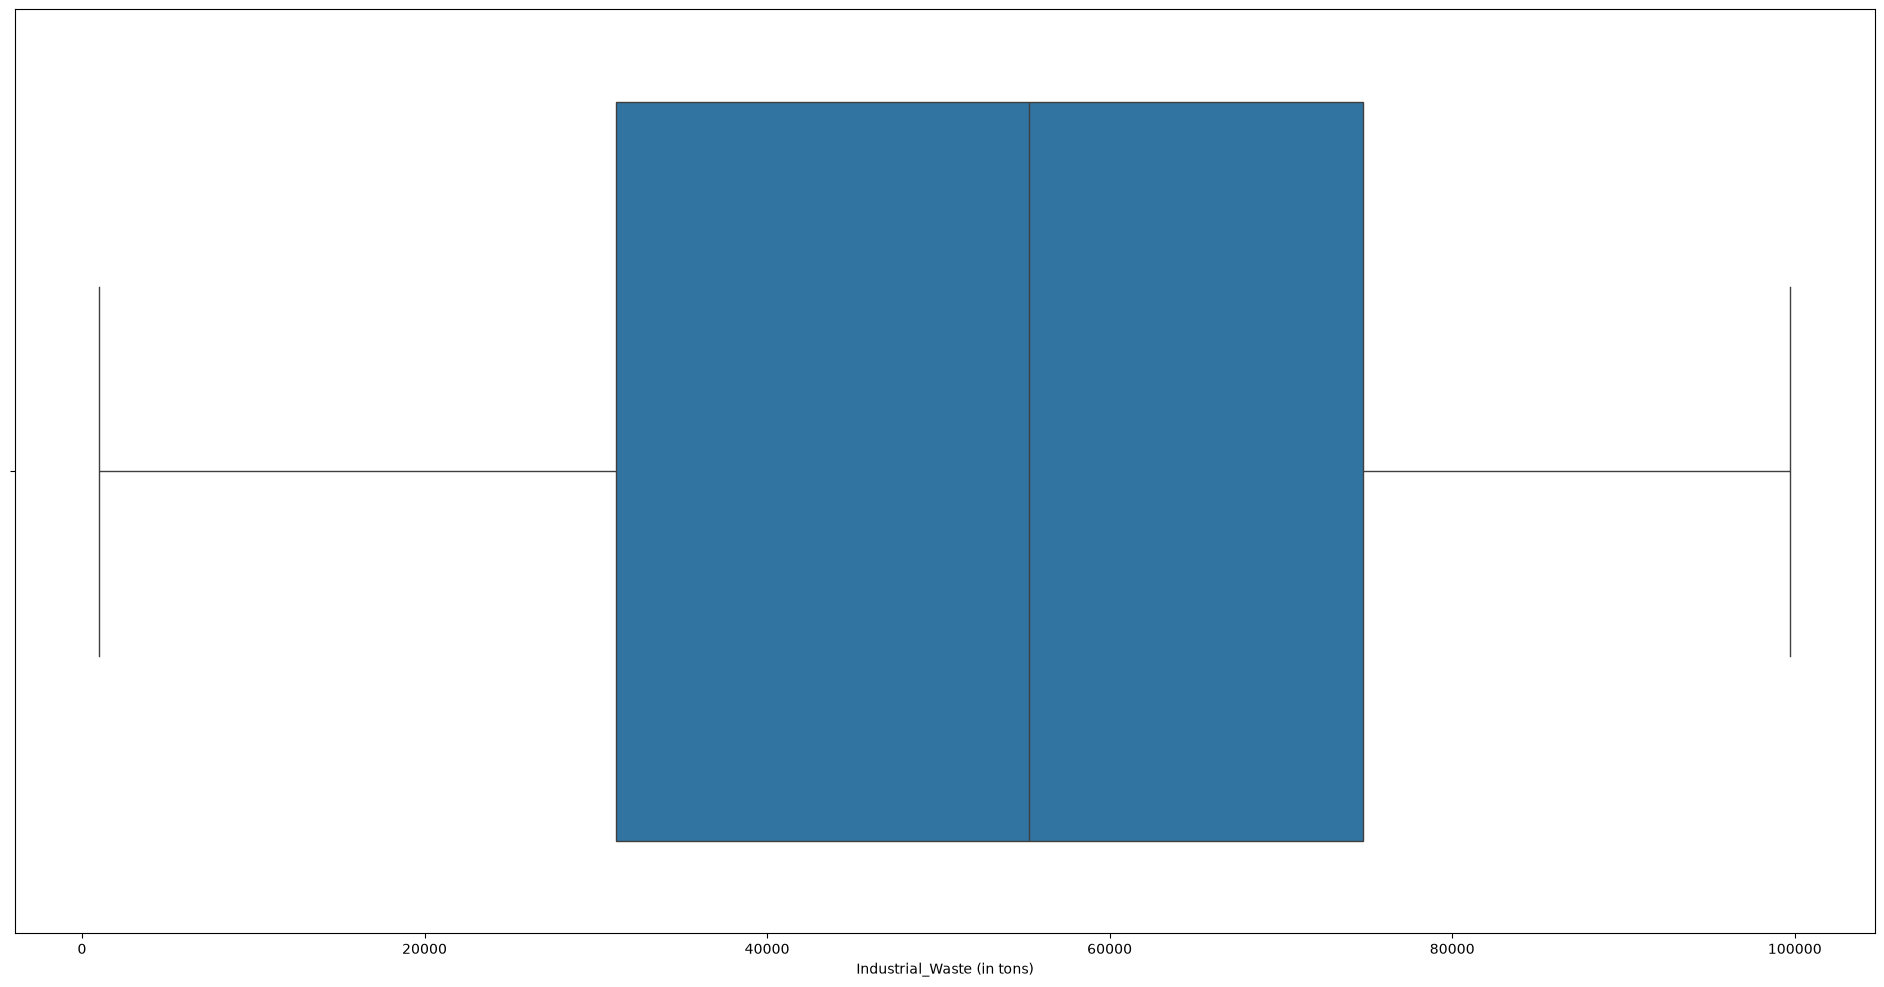

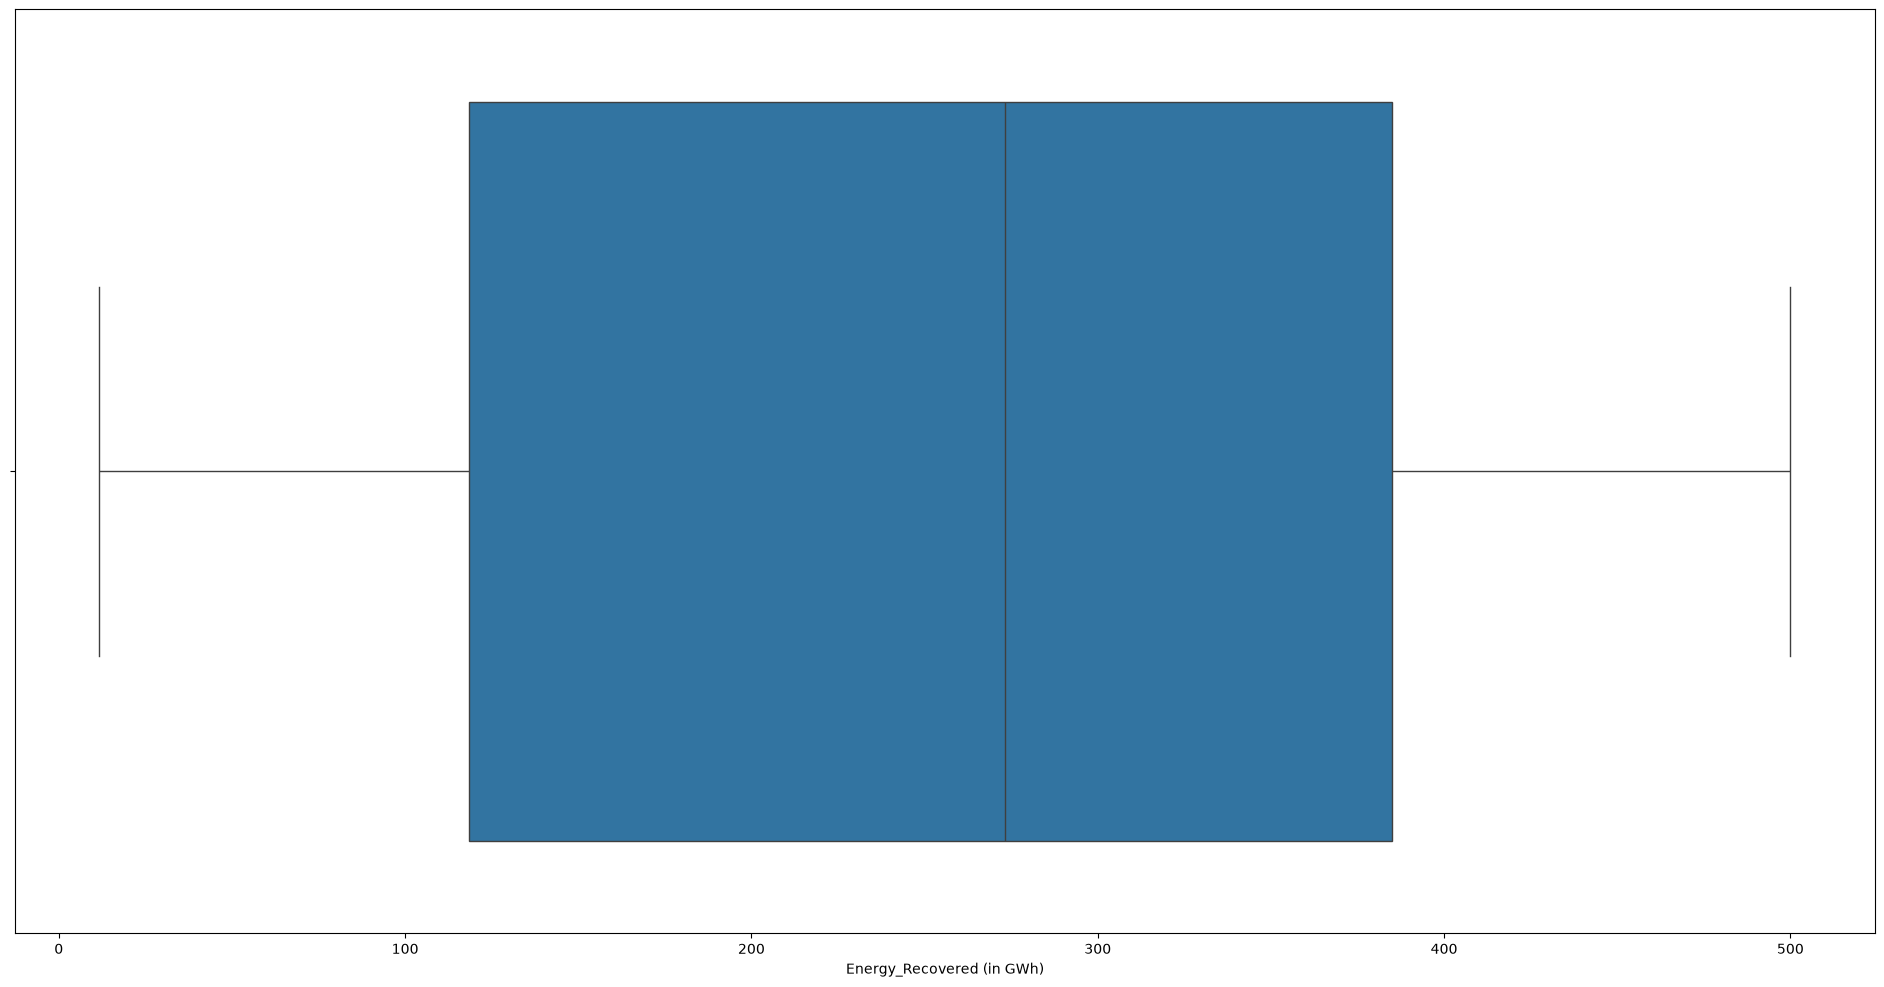

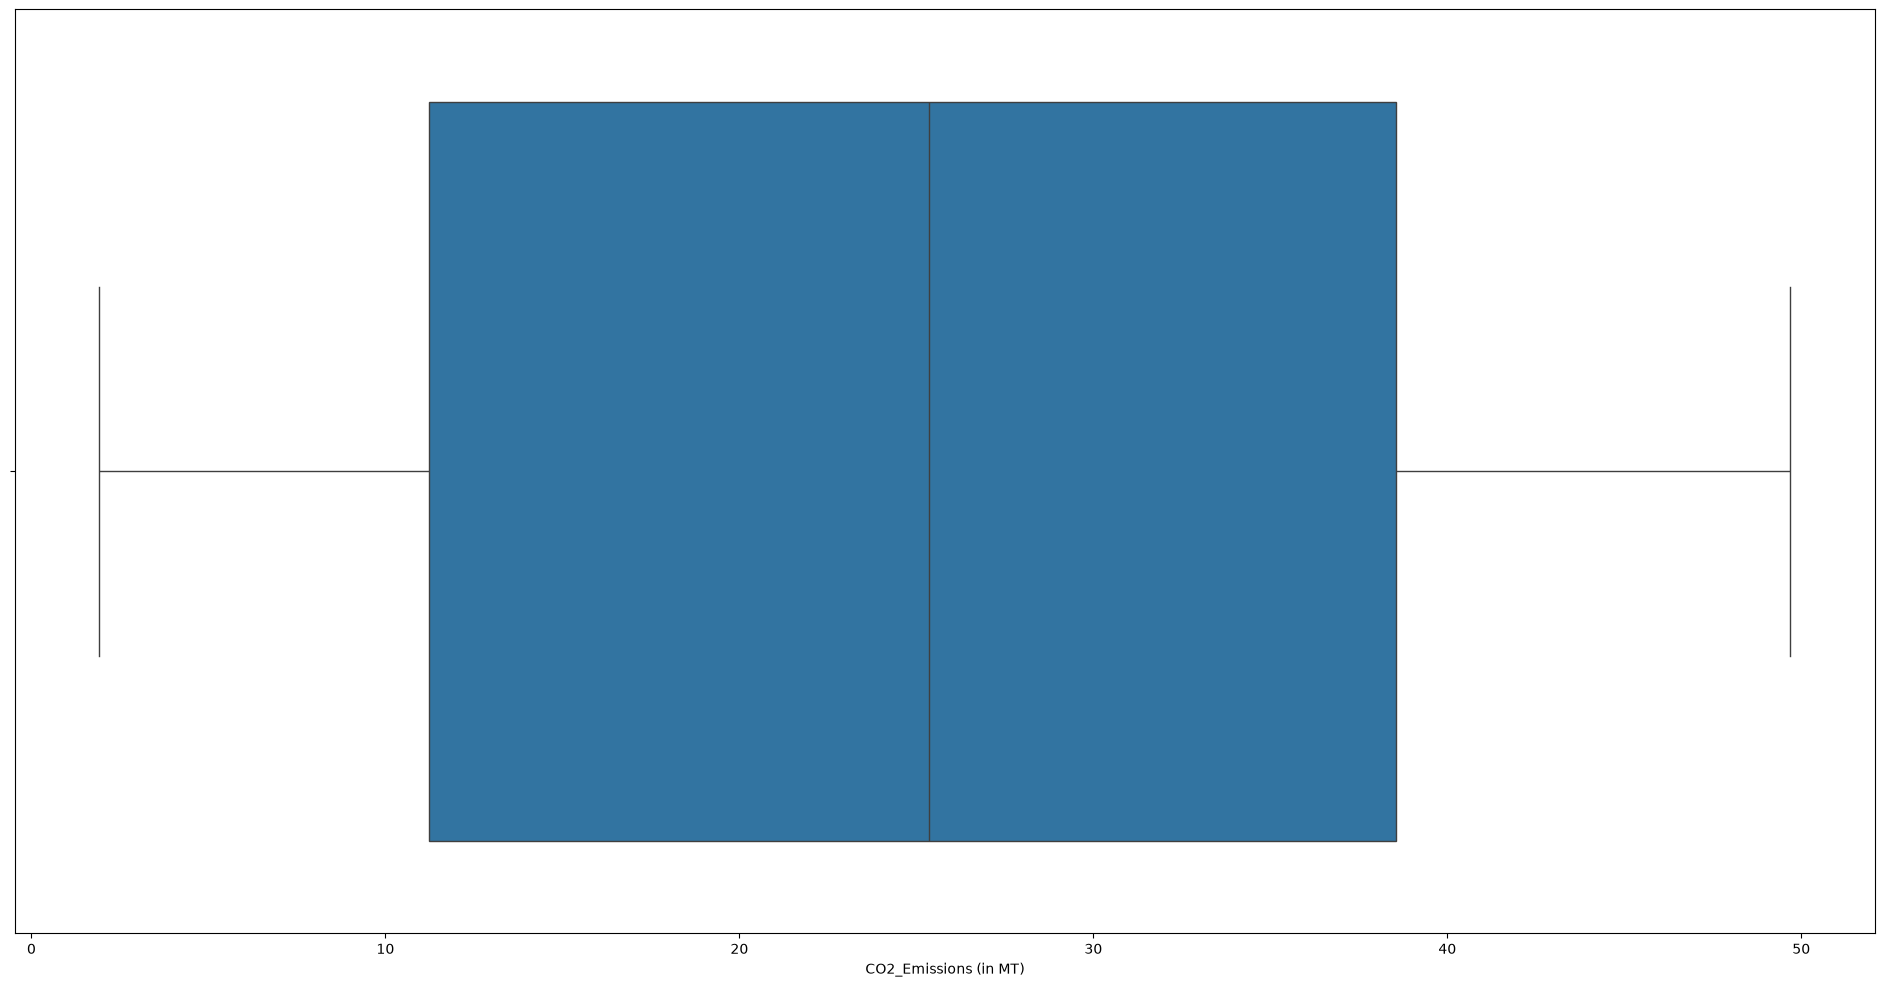

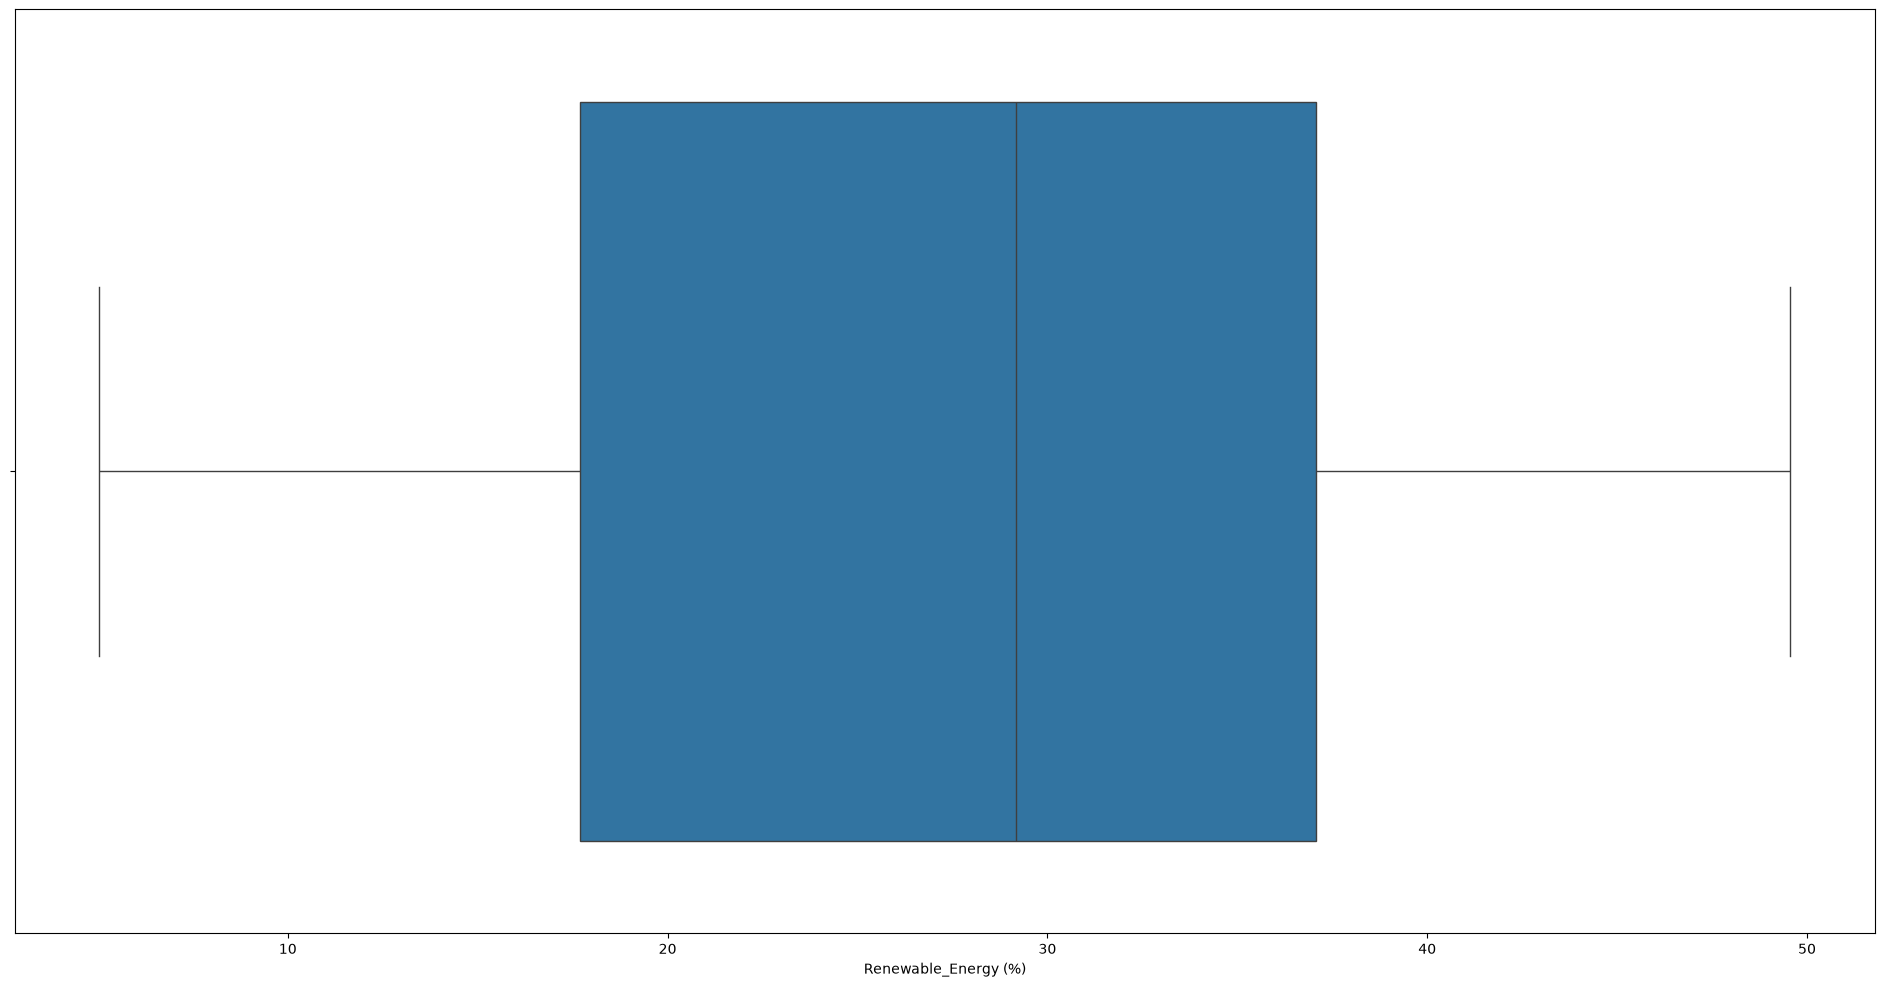

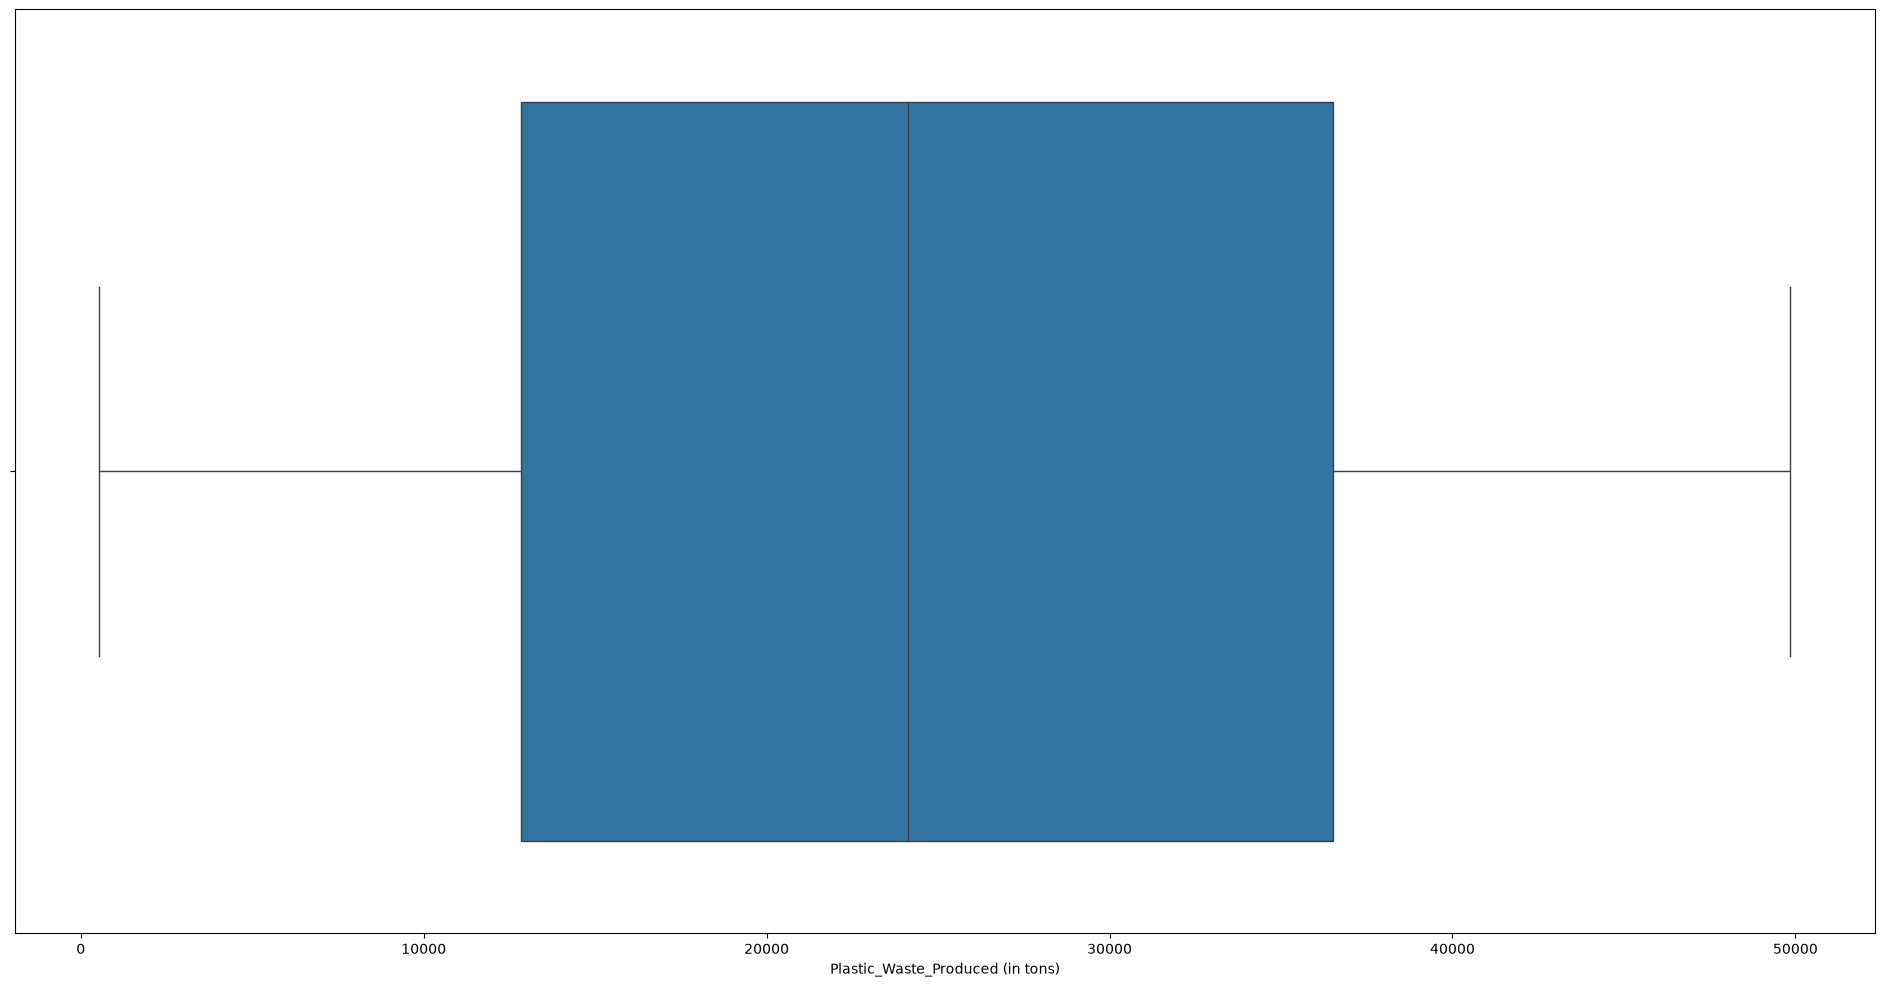

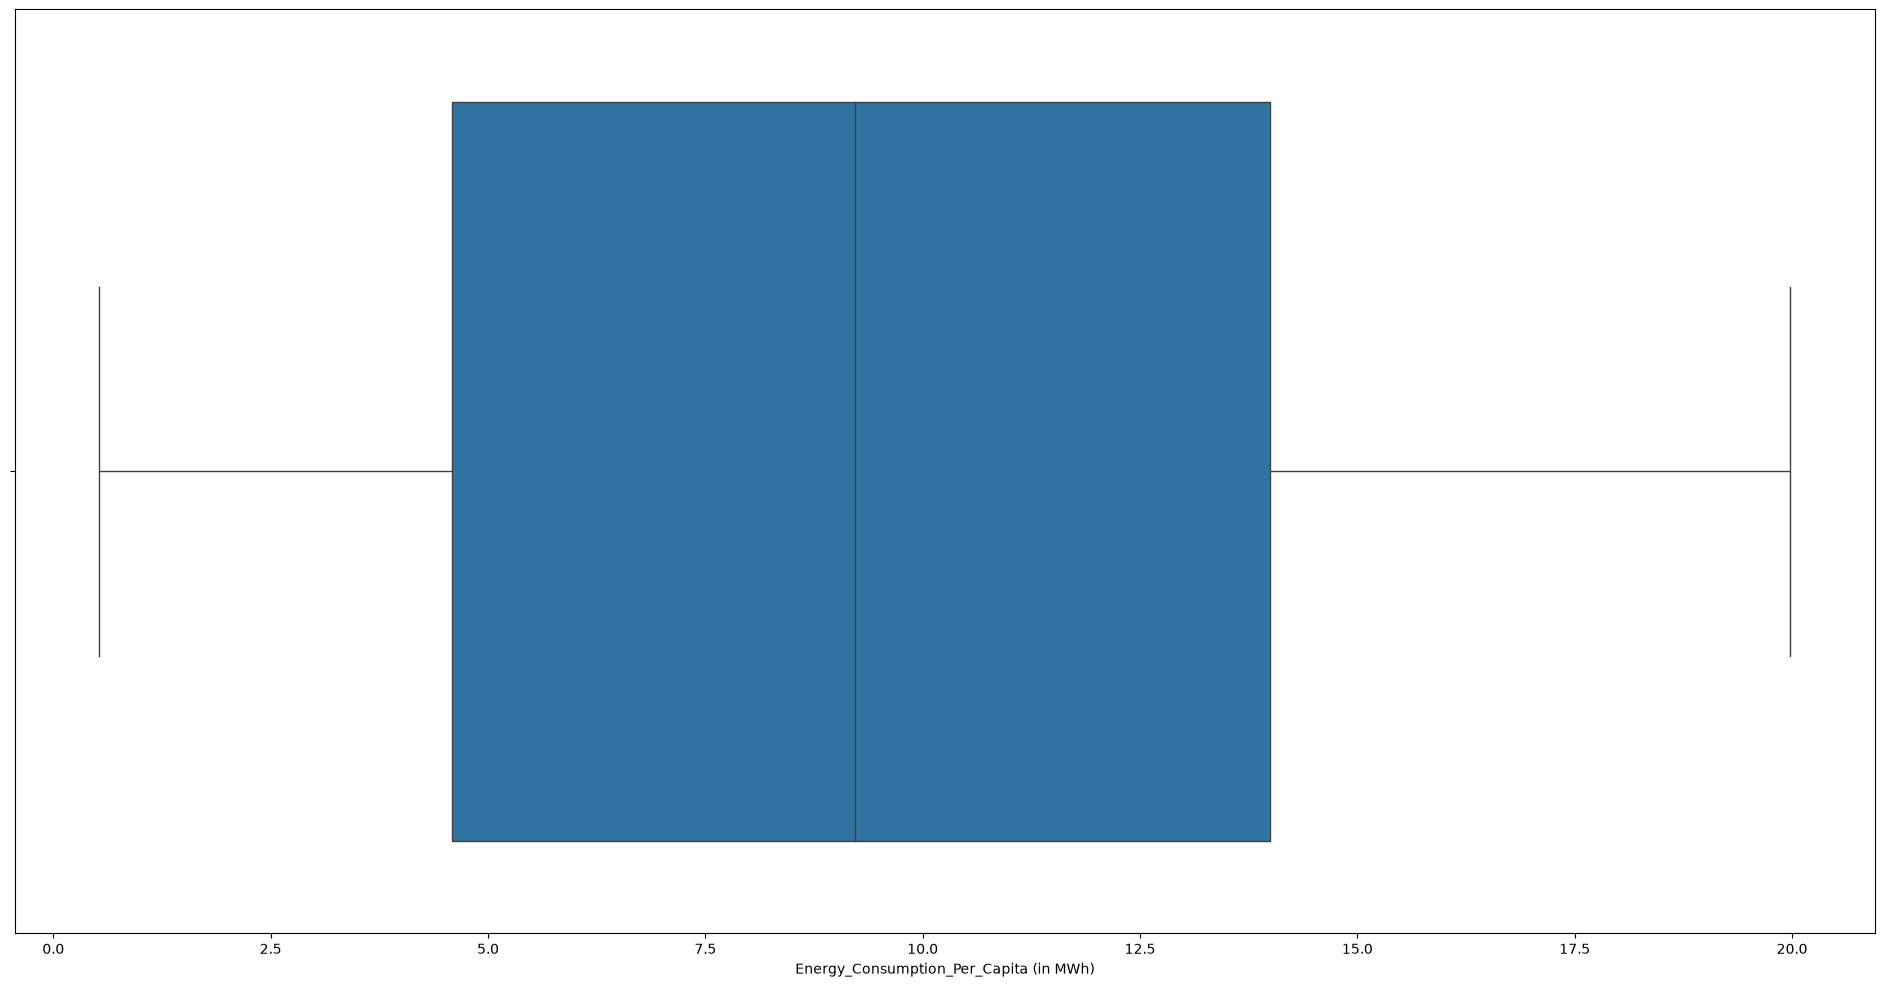

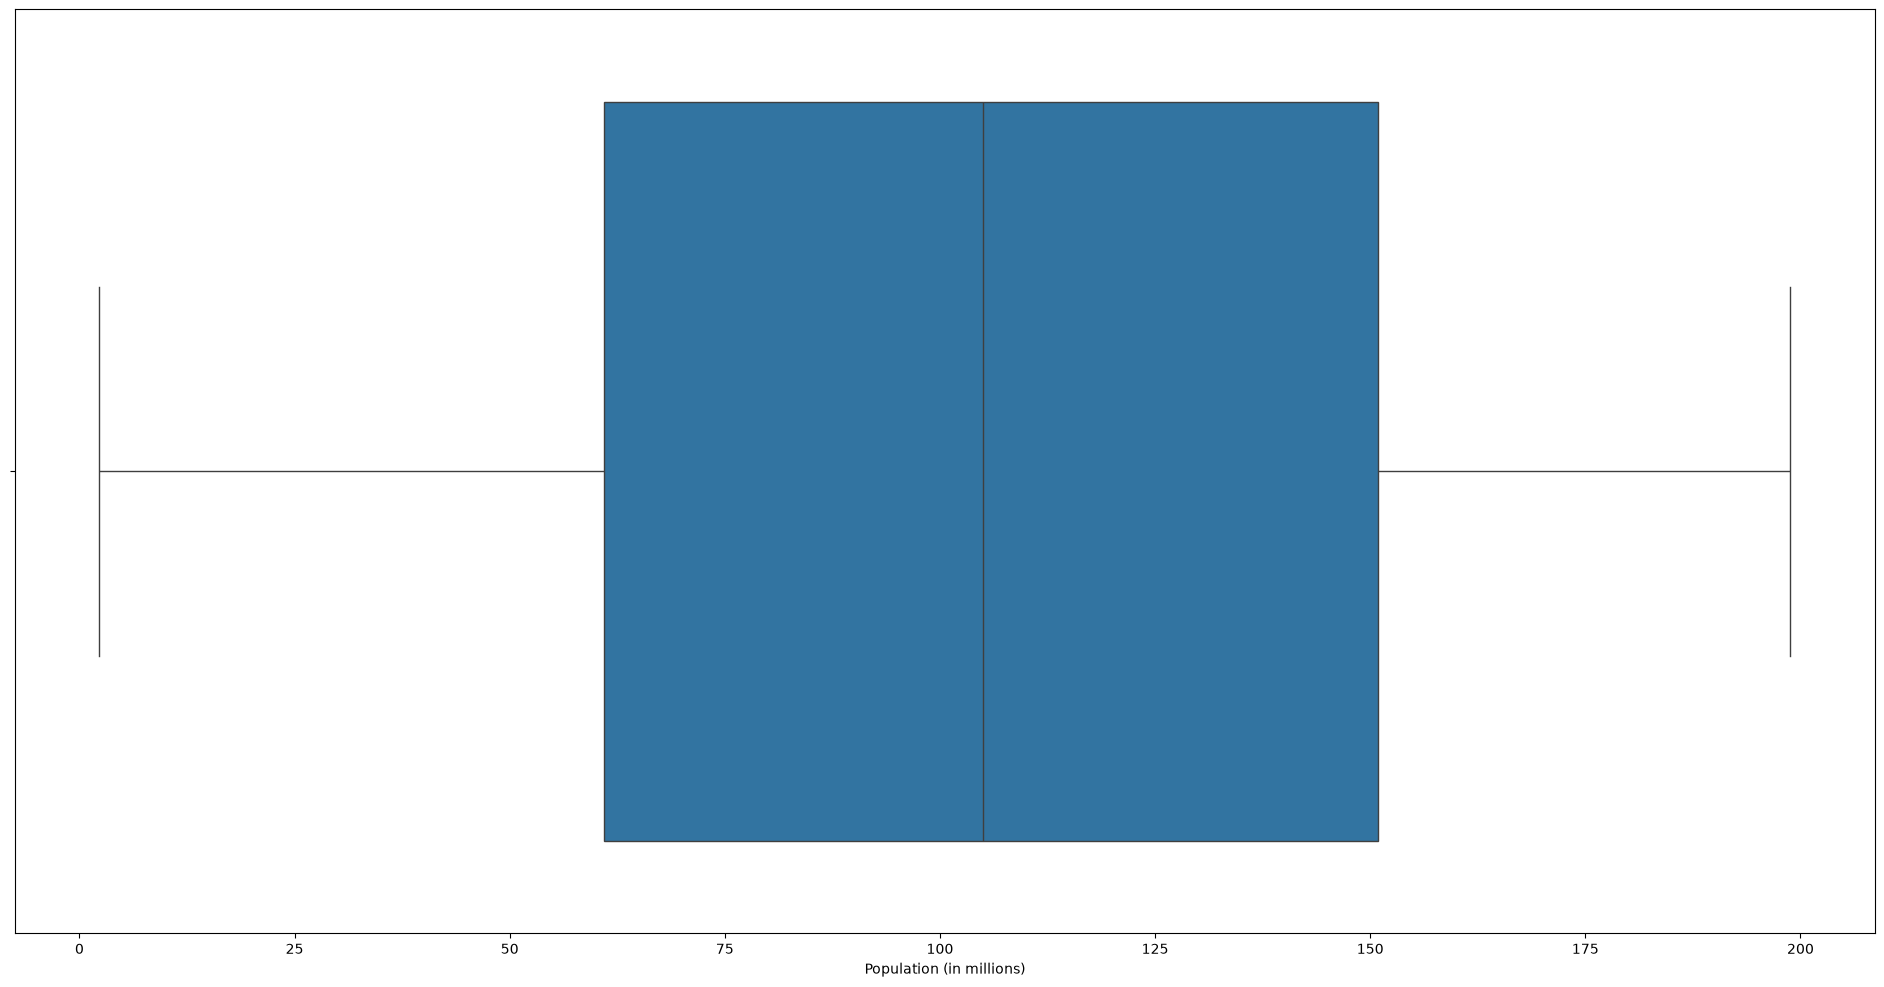

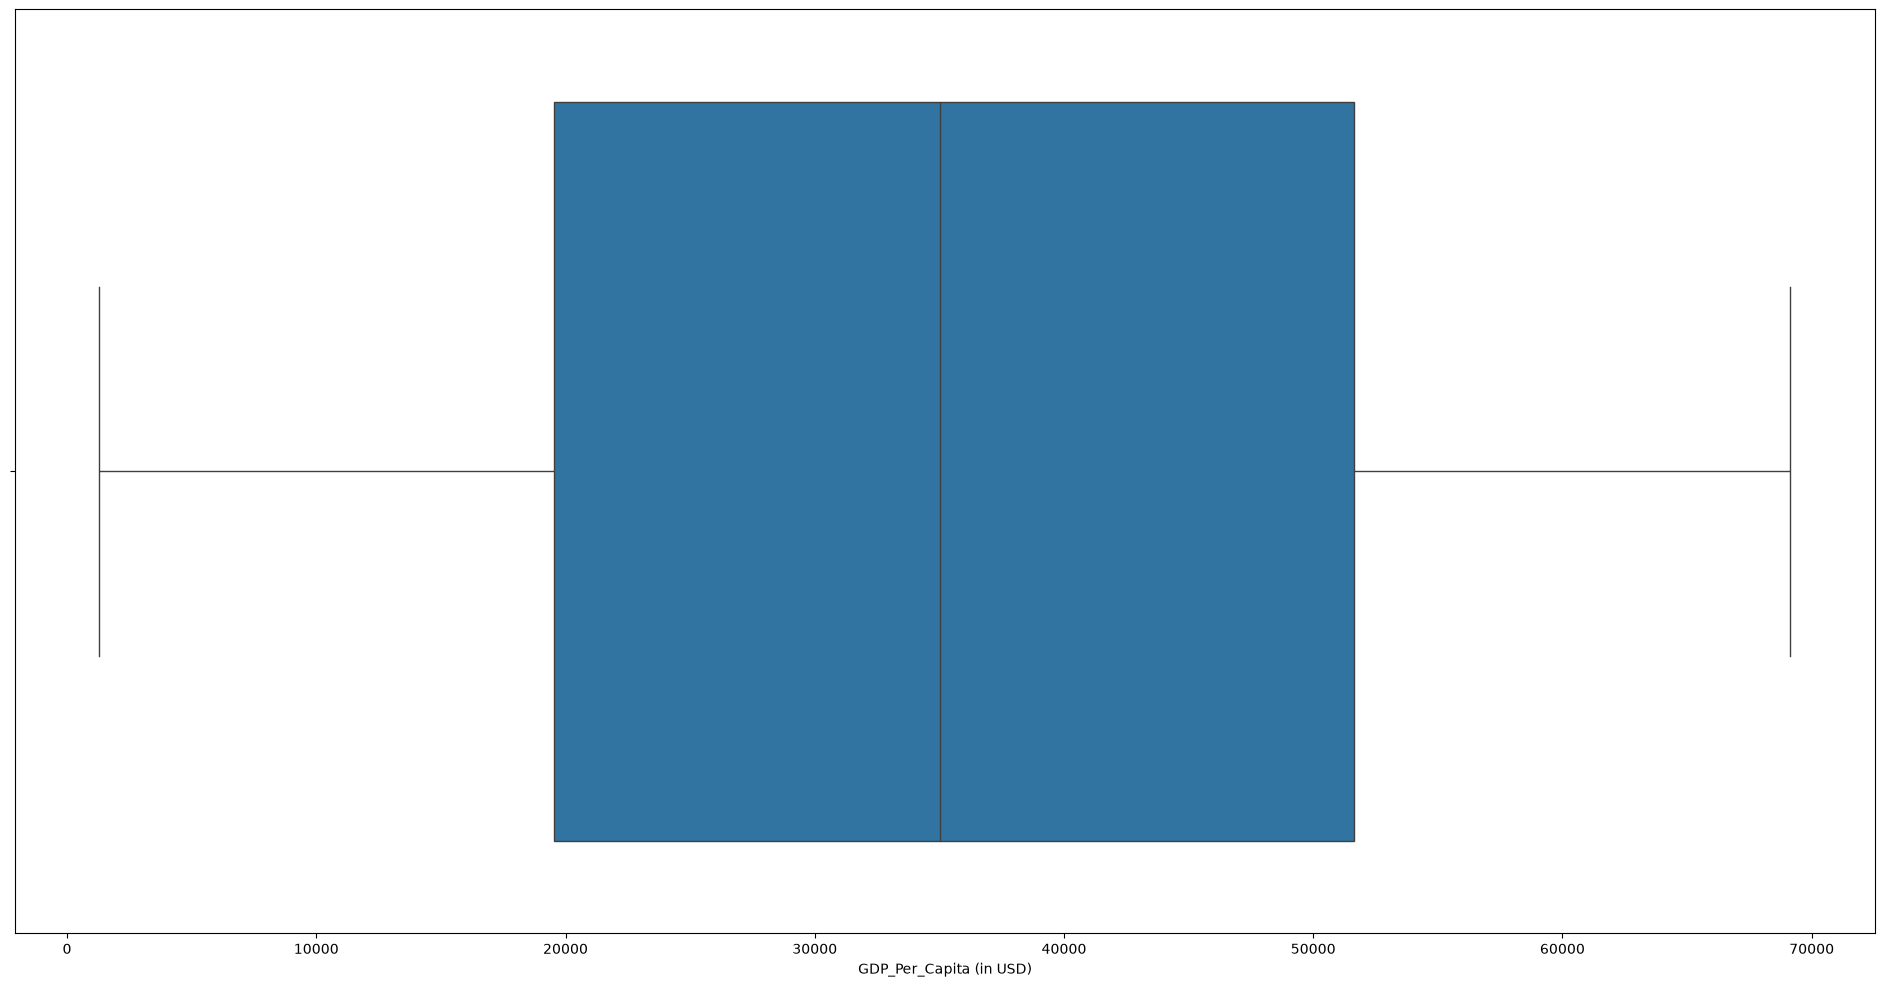

In [76]:
numeric_columns = df_new.select_dtypes(include='number').columns
for num_cols in numeric_columns:
    plt.figure(figsize=(24,12))
    sns.boxplot(x = df_new[num_cols] )

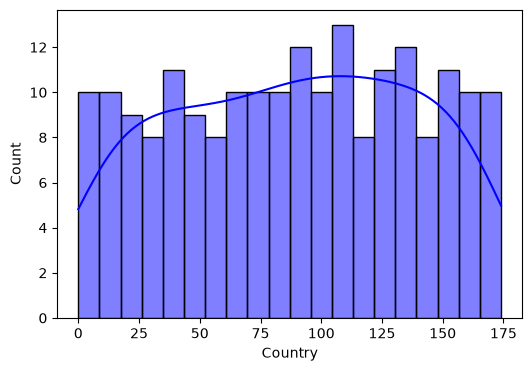

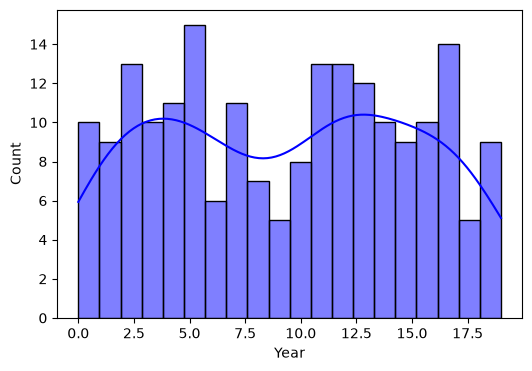

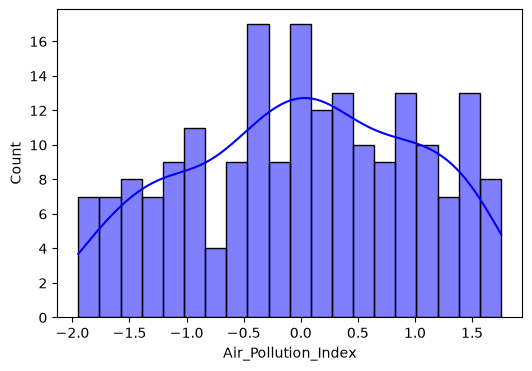

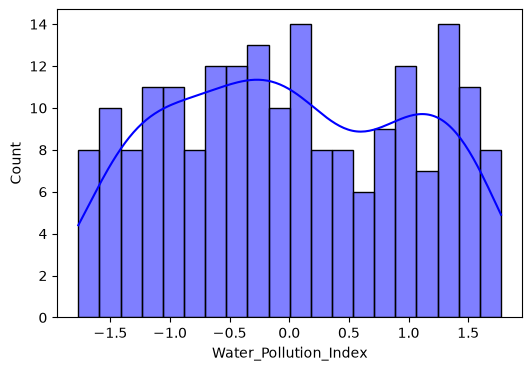

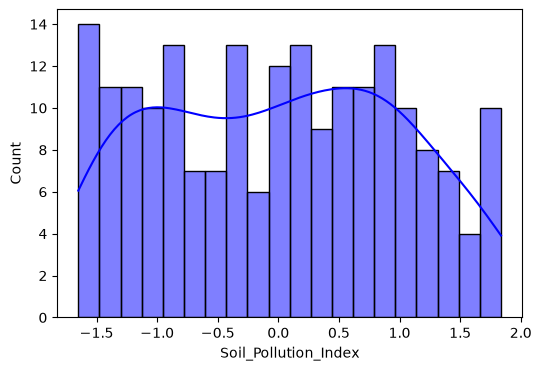

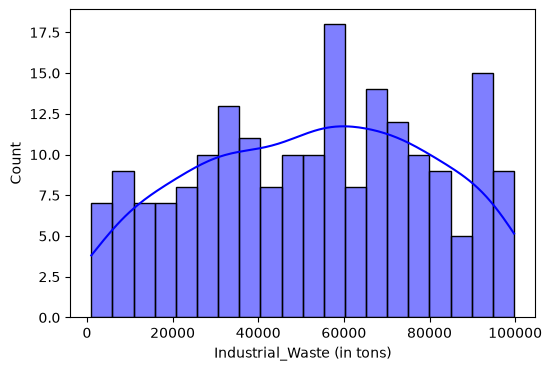

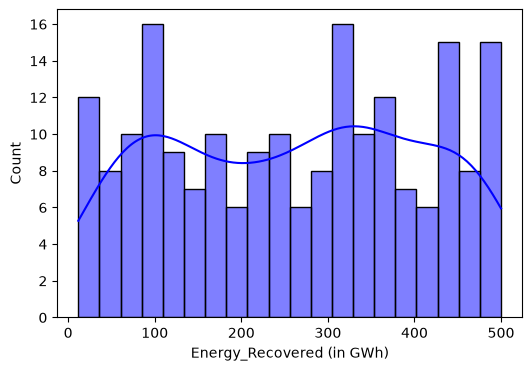

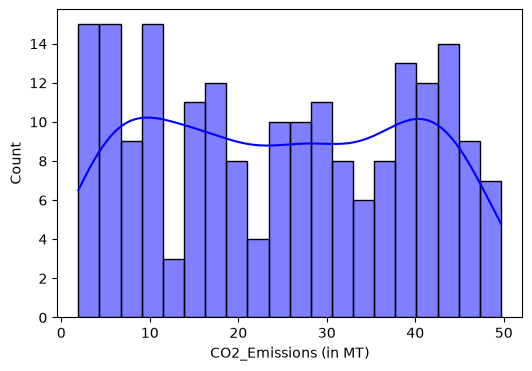

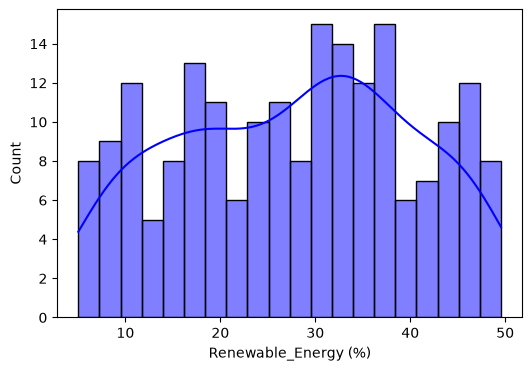

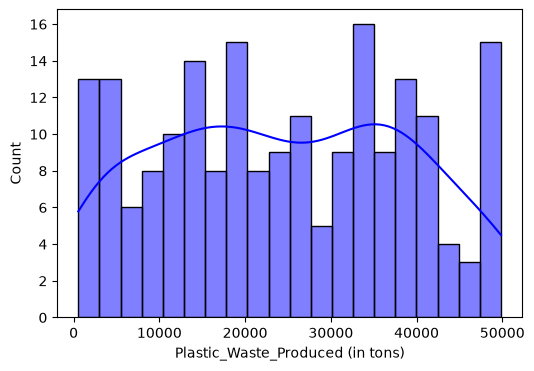

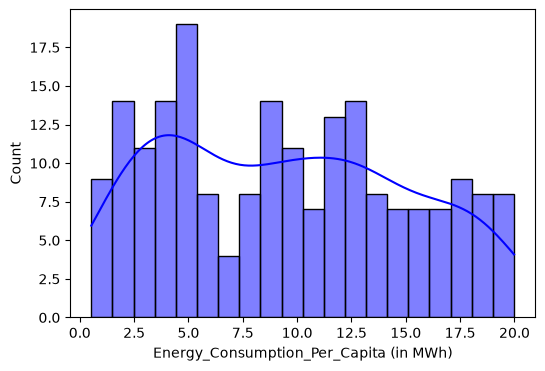

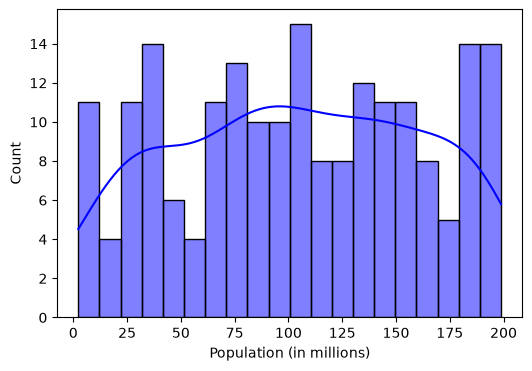

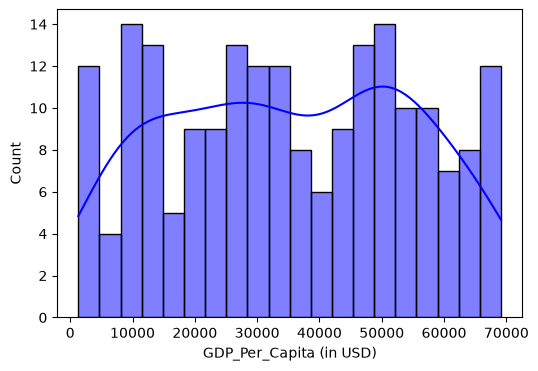

In [77]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_new[num_cols] ,kde = True,bins = 20 , color="blue"  )

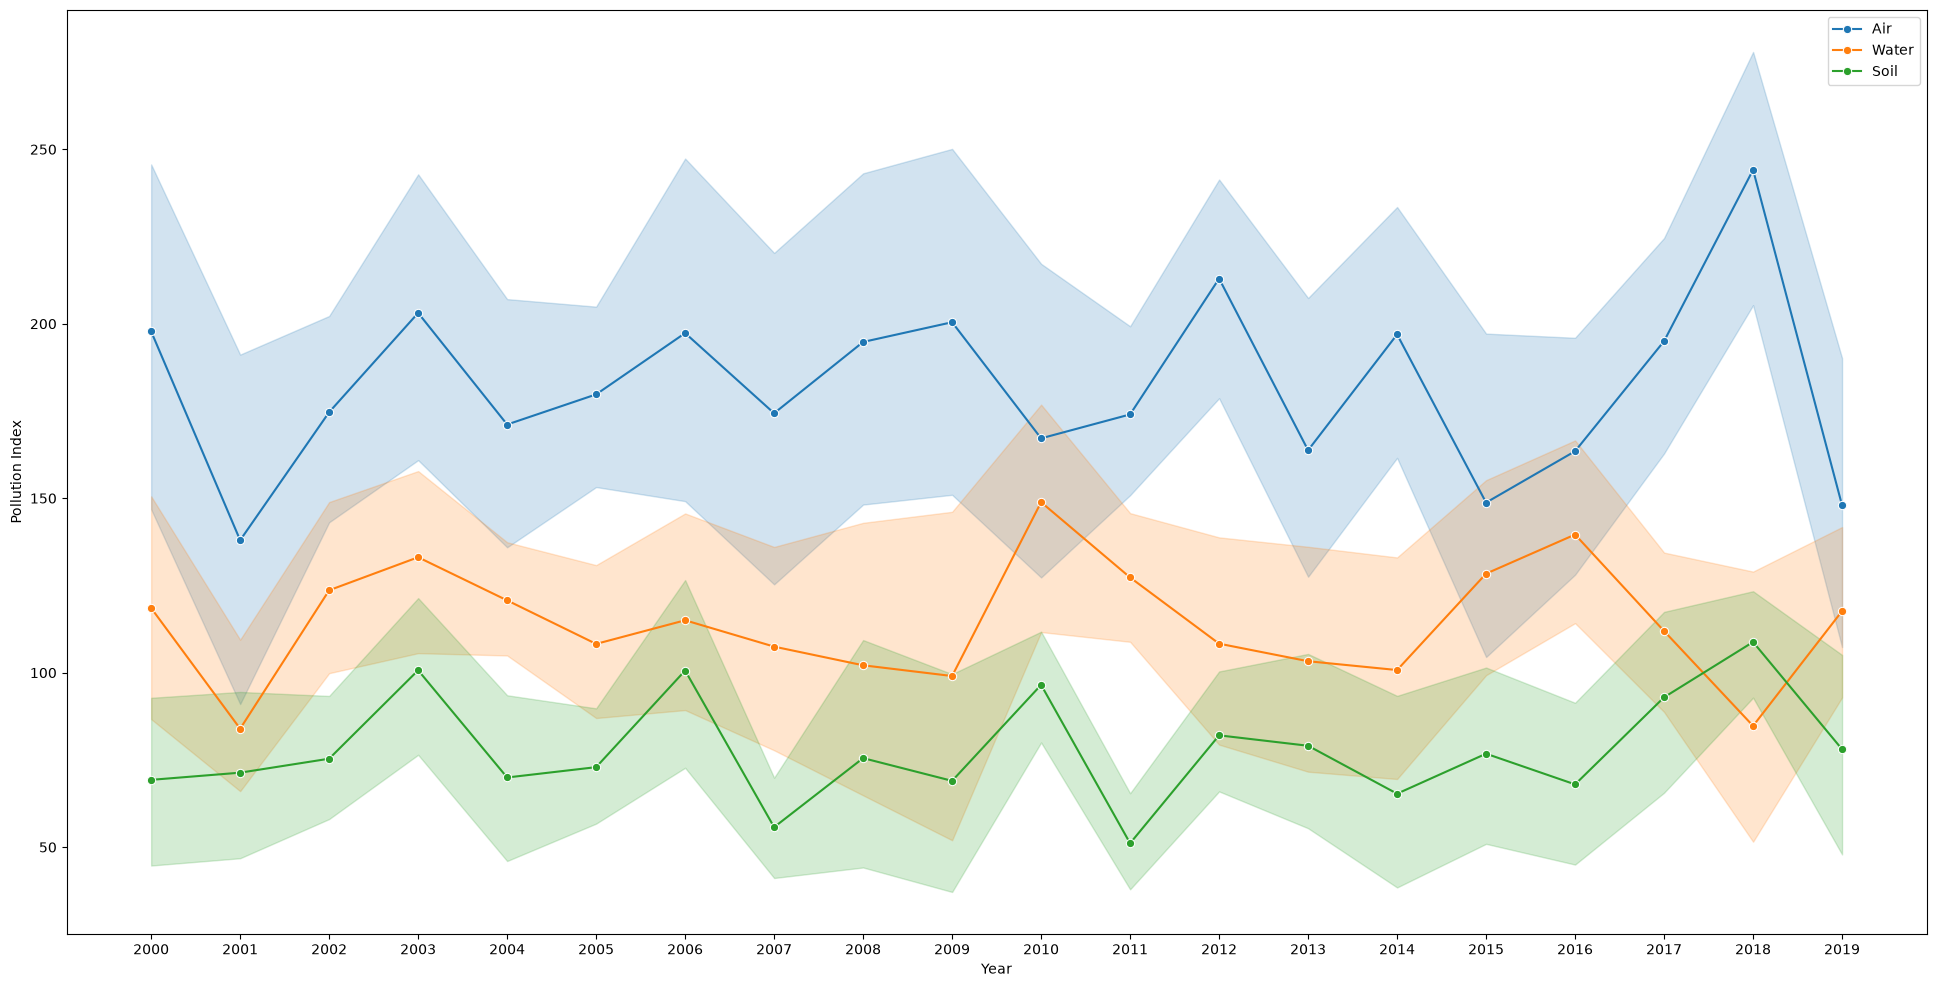

In [78]:
plt.figure(figsize=(24,12))

sns.lineplot(data=df,x='Year',y='Air_Pollution_Index',label='Air', marker='o')
sns.lineplot(data=df,x='Year',y='Water_Pollution_Index',label='Water', marker= 'o')
sns.lineplot(data=df,x='Year',y='Soil_Pollution_Index',label='Soil', marker ="o")

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Observation we get :
- Air Pollution (Blue Line): Generally fluctuating more, major peaks around 2003, 2006, 2009, 2012, and a maximum overall peak in 2018.

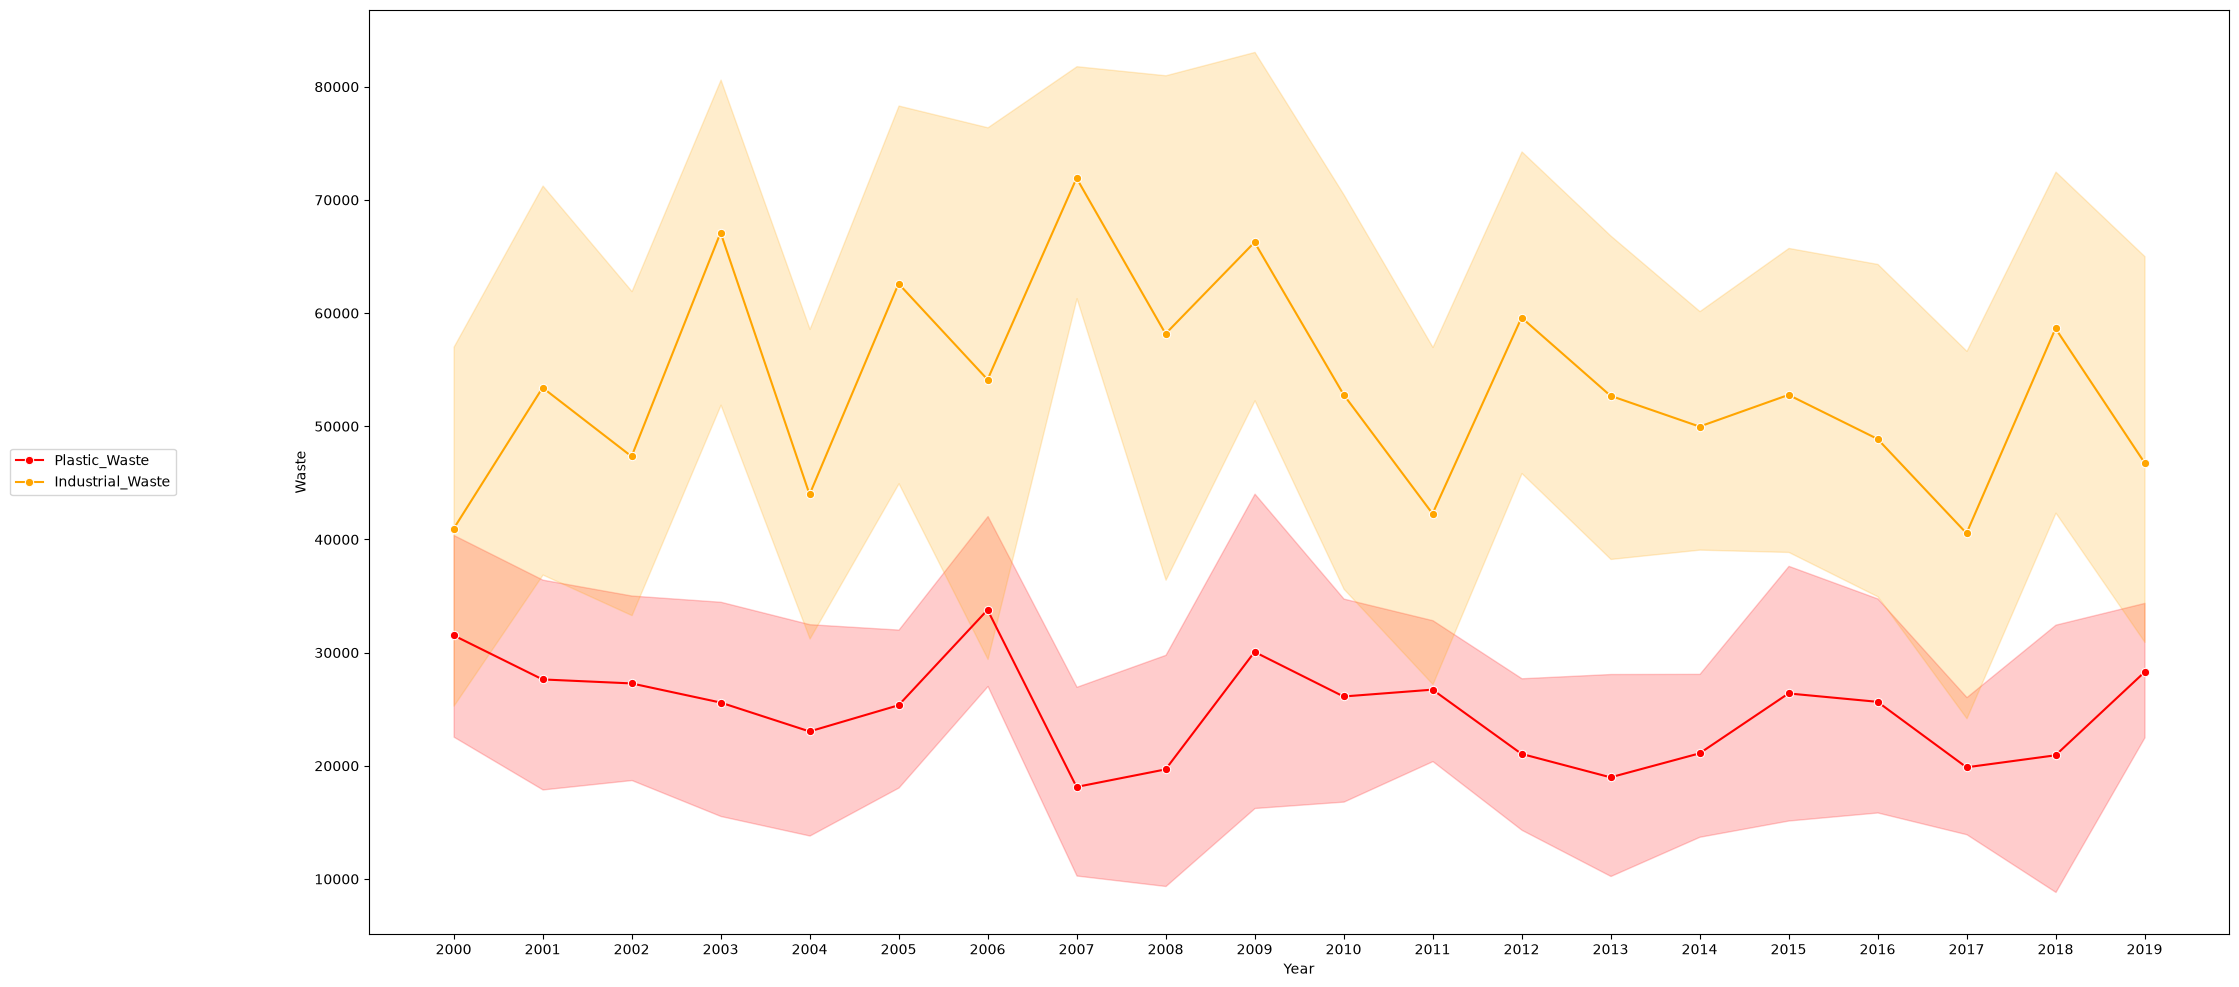

In [79]:
plt.figure(figsize=(24,12))


sns.lineplot(data=df,x='Year',y='Plastic_Waste_Produced (in tons)',label='Plastic_Waste', marker= 'o' , color='red')
sns.lineplot(data=df,x='Year',y='Industrial_Waste (in tons)',label='Industrial_Waste', marker ="o", color='orange')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Waste")

plt.legend(loc='center right', bbox_to_anchor=(-0.1, 0.5))
plt.show()


### Industrial Waste (Orange Line): Consistently remains significantly higher than plastic waste, fluctuating between roughly 40,000 and 72,000 units.

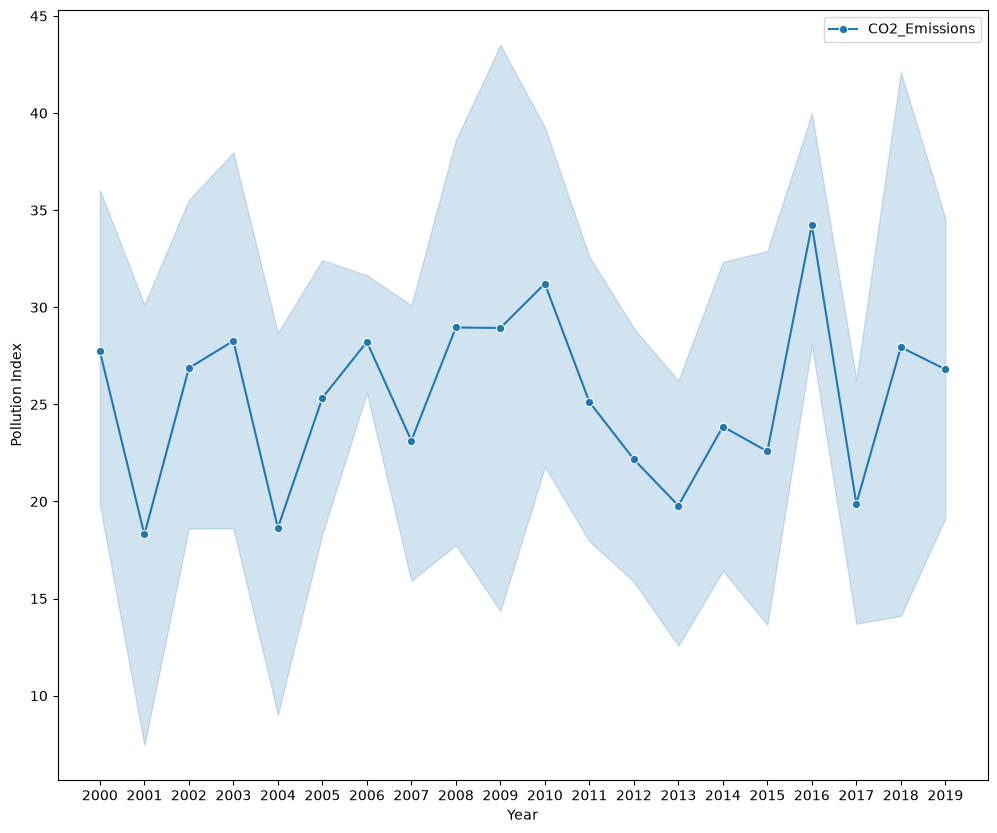

In [80]:
plt.figure(figsize=(12,10))

sns.lineplot(data=df,x='Year',y='CO2_Emissions (in MT)',label='CO2_Emissions', marker='o')

plt.xticks(range(2000, 2020))

plt.xlabel("Year")
plt.ylabel("Pollution Index")

plt.legend()
plt.show()

### Values: $\text{CO}_2$ emissions fluctuate mostly between 18 and 34 units across the 20-year period.

In [81]:
df['Average_Pollution'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

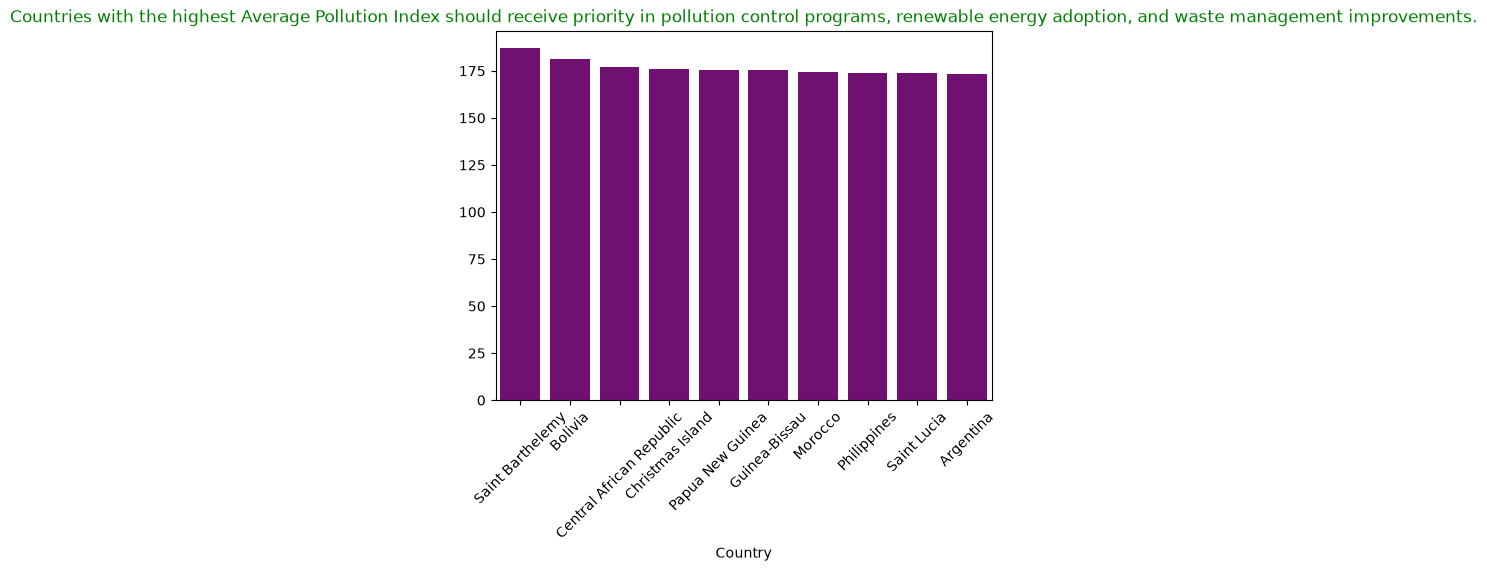

In [82]:
top10 = df.groupby('Country')['Average_Pollution'].mean().sort_values(ascending=False).head(10) # take help here :)

sns.barplot(x=top10.index, y=top10.values , color='purple')
plt.xticks(rotation=45)
plt.title("Countries with the highest Average Pollution Index should receive priority in pollution control programs, renewable energy adoption, and waste management improvements.", color="green")
plt.show()

Step 3 - Feature Engineering

In [83]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,147.116667
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,142.746667


In [84]:
yearly_trends = df.groupby("Year" , as_index=False)[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Average_Pollution",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.head()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Average_Pollution,Energy_Recovered (in GWh)
0,2000,197.796000,118.513000,69.283000,128.530667,296.889000
1,2001,137.964444,83.933333,71.340000,97.745926,288.877778
2,2002,174.661538,123.617692,75.344615,124.541282,259.750769
3,2003,203.103000,133.080000,100.687000,145.623333,208.139000
4,2004,171.120909,120.719091,69.959091,120.599697,186.458182


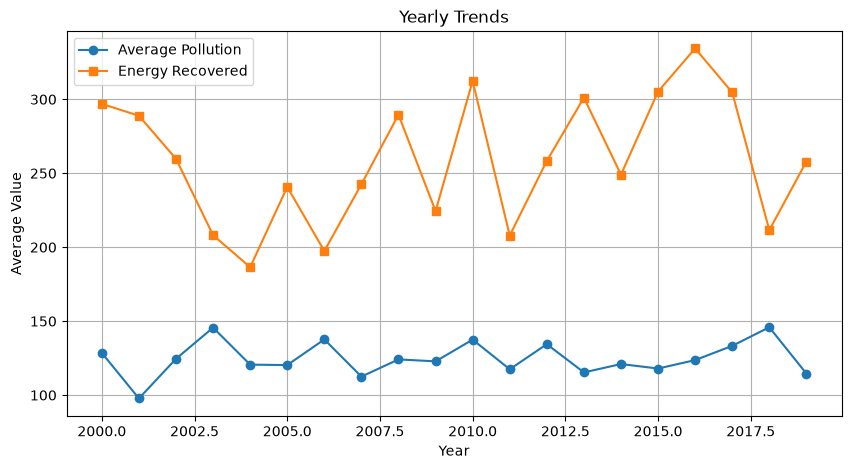

In [85]:
plt.figure(figsize=(10,5))
plt.plot(yearly_trends["Year"],
         yearly_trends["Average_Pollution"],
         marker='o',
         label="Average Pollution")

plt.plot(yearly_trends["Year"],
         yearly_trends["Energy_Recovered (in GWh)"],
         marker='s',
         label="Energy Recovered")

plt.xlabel("Year")
plt.ylabel("Average Value")
plt.title("Yearly Trends")
plt.legend()
plt.grid(True)

plt.show()

Energy_Consumption_Per_Capita (in MWh) is already given in the features , so no feature extraction

In [86]:
 
df["Pollution_Severity"] = pd.cut( 
    df["Average_Pollution"],
    bins=[0, 100, 170, float("inf")],
    labels=["Low", "Medium", "High"]
)

df["Pollution_Severity"].value_counts()

Pollution_Severity
Medium    145
Low        42
High       13
Name: count, dtype: int64

In [87]:
df['Pollution_Severity'] = le.fit_transform(df['Pollution_Severity'])

In [88]:
df.head(3)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Average_Pollution,Pollution_Severity
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,149.640000,2
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,88.093333,1
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,98.890000,1


In [89]:
X_cluster = df[[
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    "Industrial_Waste (in tons)",
    'Energy_Consumption_Per_Capita (in MWh)',
    'Energy_Recovered (in GWh)',
    'Renewable_Energy (%)'
]]

## **2. K-Mean Clustering**

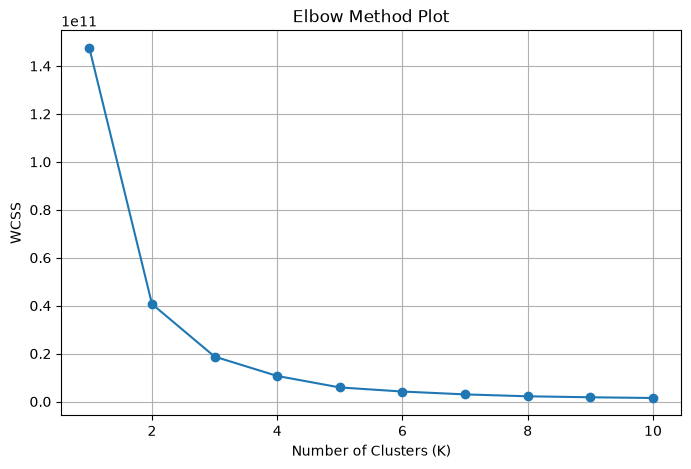

In [90]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)

  kmeans.fit(X_cluster)

  wcss.append(kmeans.inertia_)


#Plot

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method Plot")
plt.grid(True)
plt.show()

- Using Silehoutte-score for choosing the optimal value of k

In [91]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)

    silhouette_scores.append(score)

    print(f"K={k}, Score={score:.4f}")
    

K=2, Score=0.6048
K=3, Score=0.5642
K=4, Score=0.5612
K=5, Score=0.5848
K=6, Score=0.5731
K=7, Score=0.5783
K=8, Score=0.5922
K=9, Score=0.5882
K=10, Score=0.5651


<h3><b>The optimal number of clusters (k) was determined using the Elbow Method and Silhouette Analysis, which are standard hyperparameter tuning techniques for K-Means clustering.

Both methods goes for, Optimal K = 2

Elbow Method → bend around K = 2

Silhouette Score → highest at K = 2 </b></h3>

In [92]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_cluster)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 7)","[[182

In [93]:
df['Cluster'] = kmeans.labels_

<Axes: xlabel='Air_Pollution_Index', ylabel='Energy_Recovered (in GWh)'>

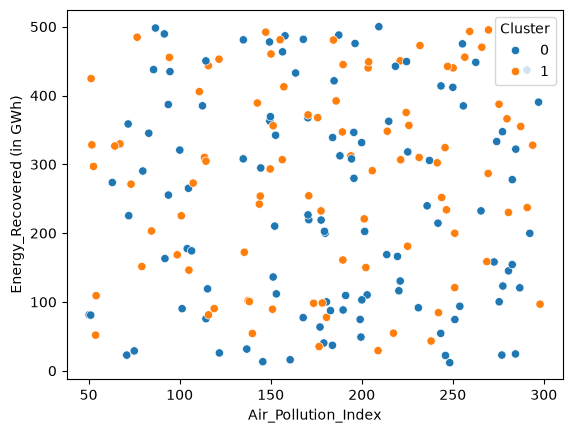

In [94]:


sns.scatterplot(
    x='Air_Pollution_Index',
    y='Energy_Recovered (in GWh)',
    hue='Cluster',
    data=df
)

<b><i>The above plot, energy recovered v/s air pollution index, is so randomly spread and we are not able to identify the clusters because K-means didn't use only two features. It uses many features or dimensions. So what we are seeing is just a projection, not the real clustering space.
So now we are going to use PCA to compress the many features into two distinct features or directions. But these are not the original features. These are just the combinations Of the many features.
And to understand the structure of the PCA, we are using the average of the original feature, using this : 
``` 
df.groupby('Cluster')[X_cluster.columns].mean()
```
</b></i>

<Axes: xlabel='PCA1', ylabel='PCA2'>

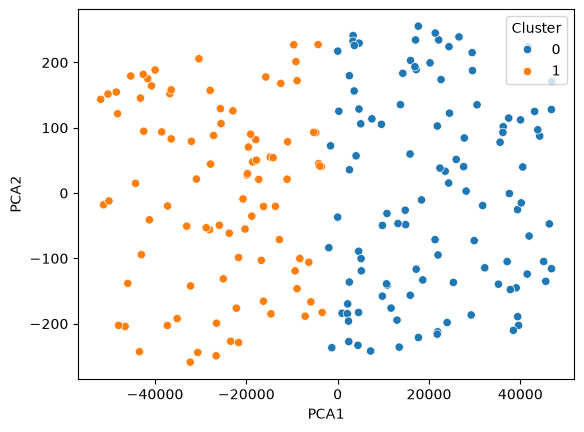

In [95]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)


df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='tab10'
)

In [96]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=X_cluster.columns,
    index=['PCA1', 'PCA2']
)

print(pca_components)

      Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
PCA1             0.000082               0.000220              0.000039   
PCA2             0.005128              -0.008045              0.020488   

      Industrial_Waste (in tons)  Energy_Consumption_Per_Capita (in MWh)  \
PCA1                    1.000000                                0.000004   
PCA2                    0.000872                               -0.001080   

      Energy_Recovered (in GWh)  Renewable_Energy (%)  
PCA1                  -0.000872             -0.000068  
PCA2                   0.999742              0.001665  


In [97]:
df.groupby('Cluster')[X_cluster.columns].mean()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Consumption_Per_Capita (in MWh),Energy_Recovered (in GWh),Renewable_Energy (%)
Cluster,,,,,,,
0,182.448545,117.597455,77.070636,73795.560182,9.531273,242.170182,26.807636
1,178.400556,111.976667,75.777111,27342.496444,9.319000,282.789111,29.012222


Countries are mainly separated along one main factor (PCA1).

If we look at the graph:

Cluster 0 has more industrial waste and less energy recovery
Cluster 1 has more renewable energy and better recovery

So, this main factor (PCA1) is basically a scale—from industrial-heavy countries on one side to more sustainable countries on the other.

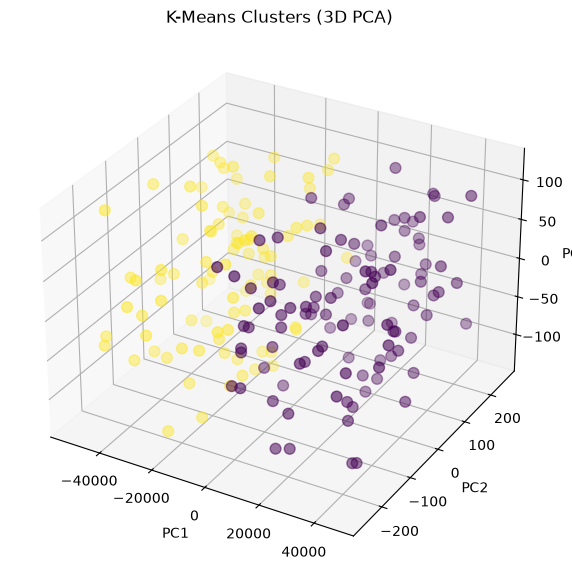

In [98]:

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_cluster)

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=df['Cluster'],
    s=60,
    alpha=0.8
    
)

ax.set_title('K-Means Clusters (3D PCA)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


plt.show()

**K-Means Clustering Analysis**
*   Dataset was standardized before clustering to ensure equal contribution of all features.
*   The Elbow Method and Silhouette Analysis were used to determine the optimal number of clusters.
*   Both methods suggested K = 2 as the optimal number of clusters.
*   The highest Silhouette Score obtained was 0.6048.
*   The low Silhouette Score (K=2, Score=0.6048) suggests moderate cluster separation among fetures.

## **2. Hierarchical Clustering**

In [99]:
X = df[[
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    "Industrial_Waste (in tons)",
    'Energy_Consumption_Per_Capita (in MWh)',
    'Energy_Recovered (in GWh)',
    'Renewable_Energy (%)'
]]

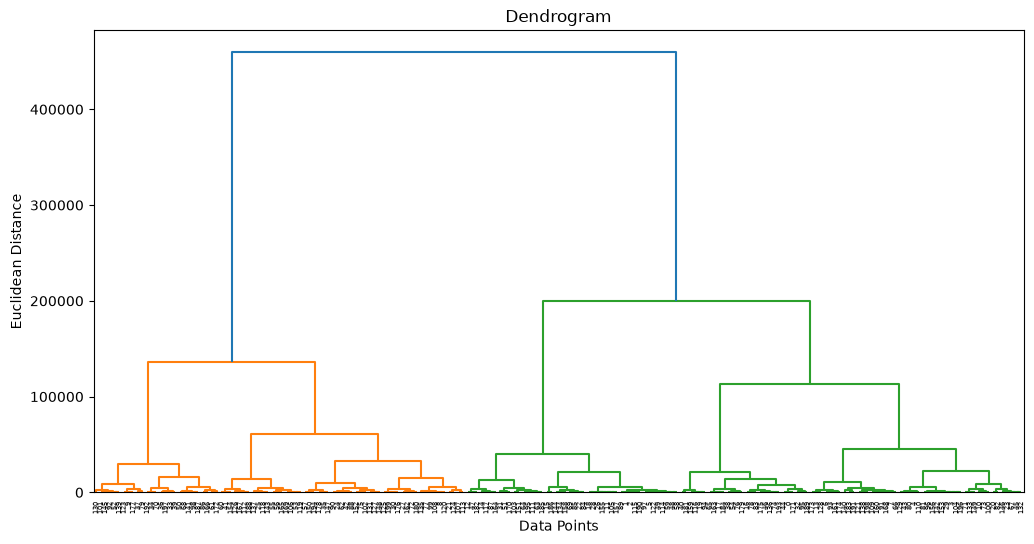

In [100]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12,6))

dendrogram(
    linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.show()

Cutting the dendrogram around 200,000 distance(approx) gives 2 clusters.

In [101]:
df.dtypes

Country                                    object
Year                                        int64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in USD)                   float64
Average_Pollution                         float64
Pollution_Severity                          int64
Cluster                                     int32
PCA1                                      float64
PCA2                                      float64
dtype: object

In [102]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

df['HC_Cluster'] = hc.fit_predict(
   X
)

In [103]:
df['HC_Cluster'].value_counts()

HC_Cluster
0    120
1     80
Name: count, dtype: int64

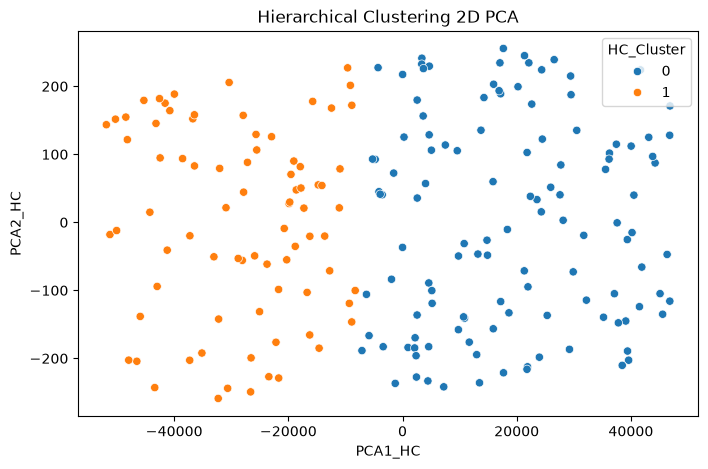

In [104]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


df['PCA1_HC'] = X_pca[:, 0]
df['PCA2_HC'] = X_pca[:, 1]

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='PCA1_HC',
    y='PCA2_HC',
    hue='HC_Cluster',
    data=df,
    palette='tab10'
)

plt.title("Hierarchical Clustering 2D PCA")
plt.show()

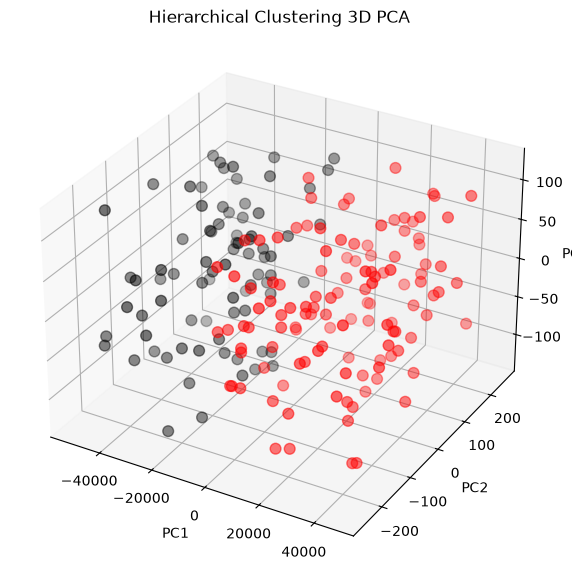

In [105]:

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=df['HC_Cluster'],
    cmap='flag',
    s=60,
    alpha=0.8
)

ax.set_title('Hierarchical Clustering 3D PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


plt.show()

### Hierarchical Clustering Analysis

- Applied Agglomerative Hierarchical Clustering using Ward linkage.
- A dendrogram was used to visualize the hierarchical structure and determine the optimal number of clusters.
- Two clusters were selected based on dendrogram analysis.
- Provide better visuals then K-mean.

In [106]:
df.columns

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)', 'Average_Pollution', 'Pollution_Severity',
       'Cluster', 'PCA1', 'PCA2', 'HC_Cluster', 'PCA1_HC', 'PCA2_HC'],
      dtype='object')

# **4. Artificial Neural Network.(ANN)**

In [107]:
from sklearn.model_selection import train_test_split


X  = df[[ 'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Industrial_Waste (in tons)',
    'CO2_Emissions (in MT)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]]

y = df['Energy_Recovered (in GWh)']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In my neural network, I am using one input layer, two hidden layers, and one output layer. And for loss we are using Mean square error, and optimizer, Adam.

In [108]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])



model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    validation_split=0.2
)


Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 94982.6094 - mae: 272.7065 - val_loss: 77444.2656 - val_mae: 238.9888
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 94915.8125 - mae: 272.5864 - val_loss: 77393.7734 - val_mae: 238.8834
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 94851.2812 - mae: 272.4720 - val_loss: 77344.2500 - val_mae: 238.7810
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 94791.9297 - mae: 272.3625 - val_loss: 77292.6719 - val_mae: 238.6740
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 94731.9531 - mae: 272.2538 - val_loss: 77242.1719 - val_mae: 238.5684
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 94672.8672 - mae: 272.1459 - val_loss: 77189.6250 - val_mae: 238.4593
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 94613.0625 - mae: 272.0355 - val_loss: 77137.3828 - val_mae: 238.3496
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 94550.8750 - mae: 271.9234 - val_loss: 77084.2734

In [109]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(loss, "", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 30122.3184 - mae: 148.0462 
30122.318359375  148.04615783691406


In [110]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
R2 Score: -0.24563823304577026


In [111]:
print("Mean Average Error :", mae)
print("Mean Square Error :", loss)
print("R²  :", r2)

Mean Average Error : 148.04615783691406
Mean Square Error : 30122.318359375
R²  : -0.24563823304577026


In [ ]:
from scikeras.wrappers import KerasRegressor # Learn something new 

In [113]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

def create_model(neurons=32, layers=1, learning_rate=0.001):
    model = Sequential()
    
    model.add(Input(shape=(X_train.shape[1],)))
    
    model.add(Dense(neurons, activation='relu'))
    
    for _ in range(layers - 1):
        model.add(Dense(neurons, activation='relu'))
    
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',   
        metrics=['mae']
    )
    
    return model

In [114]:
from sklearn.model_selection import GridSearchCV

model = KerasRegressor(model=create_model, verbose=0)

param_grid = {
    "model__neurons": [16, 32],
    "model__layers": [1, 2],
    "model__learning_rate": [0.01, 0.001],
    "batch_size": [16, 32],
    "epochs": [10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_result = grid.fit(X_train, y_train)

What KerasClassifier does -> It acts like a bridge or a "translator." Deep learning models (like Keras) and traditional machine learning models (like scikit-learn) usually don't speak the same language. By wrapping, Keras neural network inside KerasClassifier, we trick scikit-learn into thinking our complex neural network is just a simple machine learning model (like a Random Forest or Logistic Regression).

In [119]:
print("Best Params:", grid_result.best_params_)
print("Best Score:", -grid_result.best_score_)
print("Sir/Madam Out of all trials, this model configuration generate the minimum prediction error.")

Best Params: {'batch_size': 16, 'epochs': 10, 'model__layers': 2, 'model__learning_rate': 0.01, 'model__neurons': 32}
Best Score: 23778.229985304206
Sir/Madam Out of all trials, this model configuration generate the minimum prediction error.


## `ANN - Analysis (For one scenario.) `

# **Hyperparameter Tuning :**
Hyperparameter tuning was explored by experimenting with different neural network architectures, including increasing the number of hidden layers and neurons. Additional configurations such as Early Stopping were also tested.

However, the tuned models did not improve the prediction performance. The resulting R² scores became more negative and the overall test performance decreased compared to the baseline model. Therefore, the original neural network architecture was retained for the final evaluation.

# **Observation :**

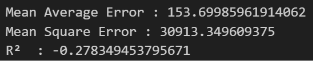



In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("Mean Average Error :", mae_lr)
print("Mean Square Error :", mse_lr)
print("R²  :", r2_lr)

Linear Regression Results
Mean Average Error : 144.33964115141197
Mean Square Error : 26311.95240859132
R²  : -0.08806943186476124


# **Observation**
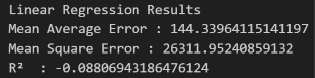

# ***Final Analysis***<br>
- The results indicate that Linear Regression outperformed the Neural Network on this dataset.

- Since the dataset is small, so neural network is not performing well.

- Also both the models, linear regression and neural network, suggesting that the features given in the dataset are not too much correlated. That's why both are giving the scores in negative.

- And if we are see the above clustering, they have successfully found from the given features.

- Finally, what we can see is that the given dataset is suitable for clustering. But when it comes to neural network, or even we can see the linear regression, it's not performed quite good.
